In [25]:
import pandas as pd
from ggner_3d.boundaries import preserved_boundaries_only, make_tads
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.cm import get_expected_cis_df, prepare_view_df, CLR_CONNS, chrom_to_bin_indices
from ggner_3d.loop_helpers import plot_anchor_loop_counts
from matplotlib import pyplot as plt

from ggner_3d import plotting
plotting.update_rcparams()

from coolpuppy import coolpup
import bioframe as bf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

window_bp = 500_000
bin_bp = 10_000
clustering_radius = 20_000 # for loops common bp
accepted_range = 1 # for tads common n bin
clr_ = CLR_CONNS(resolution=bin_bp)
NPROC = 6
WEIGHT = 'sweight'

MAXLEN=2e6
MINLEN=250_000

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [26]:
def make_tads_single_sample(df):
    boundries_df = df.loc[df[f'is_boundary_{window_bp}'] == True]
    tads = make_tads(boundries_df[['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN)
    return tads

In [27]:
comparisons_tups = [
    ('WTnoUV', 'XPCnoUV'),
    ('XPCnoUV', 'XPC3h'),
    ('WT3h', 'XPC3h'),
    ('WTnoUV', 'XPAnoUV'),
    ('XPAnoUV', 'XPA1h'),
    ('WT3h', 'XPA3h'),
    ('XPAnoUV', 'XPA3h'),
    ('XPAnoUV', 'XPA6h'),
    ('WTnoUV', 'WT3h'),
]
all_samples = list(clr_.keys())

### tads aggegated

In [13]:
insulation_tables = [
    pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/insulation/insulation_{k}_{bin_bp}bp.csv') for k in clr_.keys()
]

In [14]:
base_samples_ = ['WTnoUV', 'XPCnoUV', 'XPAnoUV']
base_samples_data = {}
for base_sample in base_samples_:
    print(f"Processing sample: {base_sample}")
    sample_i = list(clr_.keys()).index(base_sample)
    current_tads = make_tads_single_sample(insulation_tables[sample_i])
    cc = coolpup.CoordCreator(current_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    clr = clr_[base_sample]
    expected = get_expected_cis_df(base_sample, resolution_kb=bin_bp//1000, label='chrom')
    view_df = prepare_view_df(arm=False)
    pup = coolpup.PileUpper(clr, cc, expected=expected, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=NPROC, clr_weight_name=WEIGHT).pileupsWithControl()
    base_samples_data[base_sample] = pup

Processing sample: WTnoUV


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 182
INFO:coolpuppy:('chr4', 'chr4'): 190
INFO:coolpuppy:('chr5', 'chr5'): 177
INFO:coolpuppy:('chr3', 'chr3'): 208
INFO:coolpuppy:('chr1', 'chr1'): 252
INFO:coolpuppy:('chr2', 'chr2'): 228
INFO:coolpuppy:('chr9', 'chr9'): 121
INFO:coolpuppy:('chr7', 'chr7'): 146
INFO:coolpuppy:('chr10', 'chr10'): 132
INFO:coolpuppy:('chr8', 'chr8'): 151
INFO:coolpuppy:('chr11', 'chr11'): 157
INFO:coolpuppy:('chr13', 'chr13'): 90
INFO:coolpuppy:('chr12', 'chr12'): 154
INFO:coolpuppy:('chr14', 'chr14'): 103
INFO:coolpuppy:('chr16', 'chr16'): 69
INFO:coolpuppy:('chr15', 'chr15'): 93
INFO:coolpuppy:('chr19', 'chr19'): 63
INFO:coolpuppy:('chr17', 'chr17'): 85
INFO:coolpuppy:('chr18', 'chr18'): 73
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 71
INFO:coolpuppy:('chrX', 'chrX'): 133
INFO:coolpuppy:Total number of piled up windows: 2942


Processing sample: XPCnoUV


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 184
INFO:coolpuppy:('chr4', 'chr4'): 198
INFO:coolpuppy:('chr5', 'chr5'): 189
INFO:coolpuppy:('chr3', 'chr3'): 214
INFO:coolpuppy:('chr1', 'chr1'): 264
INFO:coolpuppy:('chr2', 'chr2'): 238
INFO:coolpuppy:('chr9', 'chr9'): 134
INFO:coolpuppy:('chr7', 'chr7'): 147
INFO:coolpuppy:('chr10', 'chr10'): 138
INFO:coolpuppy:('chr11', 'chr11'): 164
INFO:coolpuppy:('chr8', 'chr8'): 156
INFO:coolpuppy:('chr13', 'chr13'): 95
INFO:coolpuppy:('chr12', 'chr12'): 157
INFO:coolpuppy:('chr14', 'chr14'): 102
INFO:coolpuppy:('chr15', 'chr15'): 91
INFO:coolpuppy:('chr16', 'chr16'): 73
INFO:coolpuppy:('chr17', 'chr17'): 90
INFO:coolpuppy:('chr19', 'chr19'): 61
INFO:coolpuppy:('chr21', 'chr21'): 27
INFO:coolpuppy:('chr18', 'chr18'): 82
INFO:coolpuppy:('chr22', 'chr22'): 37
INFO:coolpuppy:('chr20', 'chr20'): 75
INFO:coolpuppy:('chrX', 'chrX'): 144
INFO:coolpuppy:Total number of piled up windows: 3060


Processing sample: XPAnoUV


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr5', 'chr5'): 165
INFO:coolpuppy:('chr6', 'chr6'): 174
INFO:coolpuppy:('chr4', 'chr4'): 178
INFO:coolpuppy:('chr3', 'chr3'): 201
INFO:coolpuppy:('chr1', 'chr1'): 235
INFO:coolpuppy:('chr2', 'chr2'): 225
INFO:coolpuppy:('chr9', 'chr9'): 117
INFO:coolpuppy:('chr7', 'chr7'): 141
INFO:coolpuppy:('chr10', 'chr10'): 123
INFO:coolpuppy:('chr8', 'chr8'): 140
INFO:coolpuppy:('chr11', 'chr11'): 148
INFO:coolpuppy:('chr13', 'chr13'): 86
INFO:coolpuppy:('chr12', 'chr12'): 142
INFO:coolpuppy:('chr16', 'chr16'): 62
INFO:coolpuppy:('chr15', 'chr15'): 85
INFO:coolpuppy:('chr17', 'chr17'): 83
INFO:coolpuppy:('chr14', 'chr14'): 95
INFO:coolpuppy:('chr19', 'chr19'): 61
INFO:coolpuppy:('chr21', 'chr21'): 24
INFO:coolpuppy:('chr18', 'chr18'): 71
INFO:coolpuppy:('chr22', 'chr22'): 35
INFO:coolpuppy:('chr20', 'chr20'): 64
INFO:coolpuppy:('chrX', 'chrX'): 130
INFO:coolpuppy:Total number of piled up windows: 2785


In [15]:
comparison_indices = [(all_samples.index(i), all_samples.index(j)) for i, j in comparisons_tups]
comparison_names = [f'{i}_{j}' for i, j in comparisons_tups]
results, dfs = preserved_boundaries_only(
    comparisons=comparison_indices,
    insulation_table_=insulation_tables,
    sample_names_str=all_samples,
    window=window_bp,
    accepted_range=accepted_range,
    comparisons_str=comparison_names
)

WTnoUV_XPCnoUV: Preserved / Increase ::: 2378
WTnoUV_XPCnoUV: Preserved / Decrease ::: 358
XPCnoUV_XPC3h: Preserved / Increase ::: 1477
XPCnoUV_XPC3h: Preserved / Decrease ::: 1203
WT3h_XPC3h: Preserved / Increase ::: 2259
WT3h_XPC3h: Preserved / Decrease ::: 401
WTnoUV_XPAnoUV: Preserved / Increase ::: 1114
WTnoUV_XPAnoUV: Preserved / Decrease ::: 1418
XPAnoUV_XPA1h: Preserved / Increase ::: 1370
XPAnoUV_XPA1h: Preserved / Decrease ::: 1106
WT3h_XPA3h: Preserved / Increase ::: 908
WT3h_XPA3h: Preserved / Decrease ::: 1692
XPAnoUV_XPA3h: Preserved / Increase ::: 1303
XPAnoUV_XPA3h: Preserved / Decrease ::: 1123
XPAnoUV_XPA6h: Preserved / Increase ::: 405
XPAnoUV_XPA6h: Preserved / Decrease ::: 1619
WTnoUV_WT3h: Preserved / Increase ::: 1560
WTnoUV_WT3h: Preserved / Decrease ::: 1002


In [16]:
bins_table = clr_['WTnoUV'].bins()[:]

In [17]:
pups_diffs_ = []

for result_index, (s1,s2) in enumerate(comparisons_tups):
    print(f'{s1} vs {s2}')
    current_df = dfs[result_index].copy()
    current_df = chrom_to_bin_indices(current_df, bins_table)
    current_tads = make_tads(current_df[['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN)

    clr1 = clr_[s1]
    clr2 = clr_[s2]
    expected1 = get_expected_cis_df(s1, resolution_kb=bin_bp//1000, label='chrom')
    expected2 = get_expected_cis_df(s2, resolution_kb=bin_bp//1000, label='chrom')

    view_df = prepare_view_df(arm=False)

    cc = coolpup.CoordCreator(current_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    pup_s1 = coolpup.PileUpper(clr1, cc, expected=expected1, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=NPROC, clr_weight_name=WEIGHT).pileupsWithControl()
    pup_s2 = coolpup.PileUpper(clr2, cc, expected=expected2, view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=NPROC, clr_weight_name=WEIGHT).pileupsWithControl()
    pups_diffs_.append((pup_s1,  pup_s2))


WTnoUV vs XPCnoUV


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 148
INFO:coolpuppy:('chr5', 'chr5'): 152
INFO:coolpuppy:('chr4', 'chr4'): 159
INFO:coolpuppy:('chr3', 'chr3'): 169
INFO:coolpuppy:('chr1', 'chr1'): 211
INFO:coolpuppy:('chr2', 'chr2'): 192
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr7', 'chr7'): 130
INFO:coolpuppy:('chr8', 'chr8'): 125
INFO:coolpuppy:('chr10', 'chr10'): 111
INFO:coolpuppy:('chr13', 'chr13'): 75
INFO:coolpuppy:('chr11', 'chr11'): 142
INFO:coolpuppy:('chr12', 'chr12'): 123
INFO:coolpuppy:('chr14', 'chr14'): 75
INFO:coolpuppy:('chr16', 'chr16'): 64
INFO:coolpuppy:('chr15', 'chr15'): 79
INFO:coolpuppy:('chr19', 'chr19'): 56
INFO:coolpuppy:('chr17', 'chr17'): 66
INFO:coolpuppy:('chr21', 'chr21'): 19
INFO:coolpuppy:('chr18', 'chr18'): 61
INFO:coolpuppy:('chr22', 'chr22'): 28
INFO:coolpuppy:('chr20', 'chr20'): 65
INFO:coolpuppy:('chrX', 'chrX'): 91
INFO:coolpuppy:Total number of piled up windows: 2440
INFO:coolpuppy:Re

XPCnoUV vs XPC3h


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 150
INFO:coolpuppy:('chr5', 'chr5'): 150
INFO:coolpuppy:('chr4', 'chr4'): 157
INFO:coolpuppy:('chr3', 'chr3'): 169
INFO:coolpuppy:('chr1', 'chr1'): 209
INFO:coolpuppy:('chr2', 'chr2'): 180
INFO:coolpuppy:('chr9', 'chr9'): 108
INFO:coolpuppy:('chr7', 'chr7'): 121
INFO:coolpuppy:('chr8', 'chr8'): 117
INFO:coolpuppy:('chr10', 'chr10'): 107
INFO:coolpuppy:('chr11', 'chr11'): 125
INFO:coolpuppy:('chr13', 'chr13'): 74
INFO:coolpuppy:('chr12', 'chr12'): 132
INFO:coolpuppy:('chr16', 'chr16'): 52
INFO:coolpuppy:('chr14', 'chr14'): 82
INFO:coolpuppy:('chr15', 'chr15'): 75
INFO:coolpuppy:('chr17', 'chr17'): 70
INFO:coolpuppy:('chr19', 'chr19'): 55
INFO:coolpuppy:('chr21', 'chr21'): 15
INFO:coolpuppy:('chr18', 'chr18'): 56
INFO:coolpuppy:('chr22', 'chr22'): 30
INFO:coolpuppy:('chr20', 'chr20'): 63
INFO:coolpuppy:('chrX', 'chrX'): 98
INFO:coolpuppy:Total number of piled up windows: 2395
INFO:coolpuppy:R

WT3h vs XPC3h


...

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr5', 'chr5'): 119
INFO:coolpuppy:('chr6', 'chr6'): 127
INFO:coolpuppy:('chr4', 'chr4'): 130
INFO:coolpuppy:('chr3', 'chr3'): 158
INFO:coolpuppy:('chr1', 'chr1'): 190
INFO:coolpuppy:('chr2', 'chr2'): 172
INFO:coolpuppy:('chr9', 'chr9'): 92
INFO:coolpuppy:('chr7', 'chr7'): 109
INFO:coolpuppy:('chr10', 'chr10'): 81
INFO:coolpuppy:('chr8', 'chr8'): 107
INFO:coolpuppy:('chr11', 'chr11'): 117
INFO:coolpuppy:('chr13', 'chr13'): 65
INFO:coolpuppy:('chr12', 'chr12'): 107
INFO:coolpuppy:('chr15', 'chr15'): 57
INFO:coolpuppy:('chr16', 'chr16'): 52
INFO:coolpuppy:('chr14', 'chr14'): 68
INFO:coolpuppy:('chr17', 'chr17'): 65
INFO:coolpuppy:('chr21', 'chr21'): 17
INFO:coolpuppy:('chr19', 'chr19'): 47
INFO:coolpuppy:('chr22', 'chr22'): 26
INFO:coolpuppy:('chr18', 'chr18'): 46
INFO:coolpuppy:('chr20', 'chr20'): 54
INFO:coolpuppy:('chrX', 'chrX'): 90
INFO:coolpuppy:Total number of piled up windows: 2096
INFO:coolpuppy:Res

XPAnoUV vs XPA6h


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 94
INFO:coolpuppy:('chr5', 'chr5'): 95
INFO:coolpuppy:('chr4', 'chr4'): 96
INFO:coolpuppy:('chr3', 'chr3'): 111
INFO:coolpuppy:('chr1', 'chr1'): 143
INFO:coolpuppy:('chr2', 'chr2'): 125
INFO:coolpuppy:('chr9', 'chr9'): 64
INFO:coolpuppy:('chr7', 'chr7'): 84
INFO:coolpuppy:('chr10', 'chr10'): 67
INFO:coolpuppy:('chr8', 'chr8'): 86
INFO:coolpuppy:('chr11', 'chr11'): 90
INFO:coolpuppy:('chr13', 'chr13'): 55
INFO:coolpuppy:('chr12', 'chr12'): 92
INFO:coolpuppy:('chr16', 'chr16'): 46
INFO:coolpuppy:('chr14', 'chr14'): 57
INFO:coolpuppy:('chr15', 'chr15'): 49
INFO:coolpuppy:('chr19', 'chr19'): 45
INFO:coolpuppy:('chr17', 'chr17'): 46
INFO:coolpuppy:('chr18', 'chr18'): 33
INFO:coolpuppy:('chr21', 'chr21'): 13
INFO:coolpuppy:('chr22', 'chr22'): 19
INFO:coolpuppy:('chr20', 'chr20'): 37
INFO:coolpuppy:('chrX', 'chrX'): 63
INFO:coolpuppy:Total number of piled up windows: 1610
INFO:coolpuppy:Rescaling 

WTnoUV vs WT3h


INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4', 'chr4'): 143
INFO:coolpuppy:('chr6', 'chr6'): 144
INFO:coolpuppy:('chr5', 'chr5'): 141
INFO:coolpuppy:('chr3', 'chr3'): 150
INFO:coolpuppy:('chr1', 'chr1'): 202
INFO:coolpuppy:('chr2', 'chr2'): 175
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr7', 'chr7'): 121
INFO:coolpuppy:('chr8', 'chr8'): 111
INFO:coolpuppy:('chr10', 'chr10'): 102
INFO:coolpuppy:('chr13', 'chr13'): 67
INFO:coolpuppy:('chr11', 'chr11'): 122
INFO:coolpuppy:('chr12', 'chr12'): 114
INFO:coolpuppy:('chr14', 'chr14'): 82
INFO:coolpuppy:('chr16', 'chr16'): 53
INFO:coolpuppy:('chr15', 'chr15'): 67
INFO:coolpuppy:('chr19', 'chr19'): 55
INFO:coolpuppy:('chr17', 'chr17'): 67
INFO:coolpuppy:('chr21', 'chr21'): 18
INFO:coolpuppy:('chr22', 'chr22'): 31
INFO:coolpuppy:('chr18', 'chr18'): 56
INFO:coolpuppy:('chr20', 'chr20'): 56
INFO:coolpuppy:('chrX', 'chrX'): 98
INFO:coolpuppy:Total number of piled up windows: 2274
INFO:coolpuppy:Re

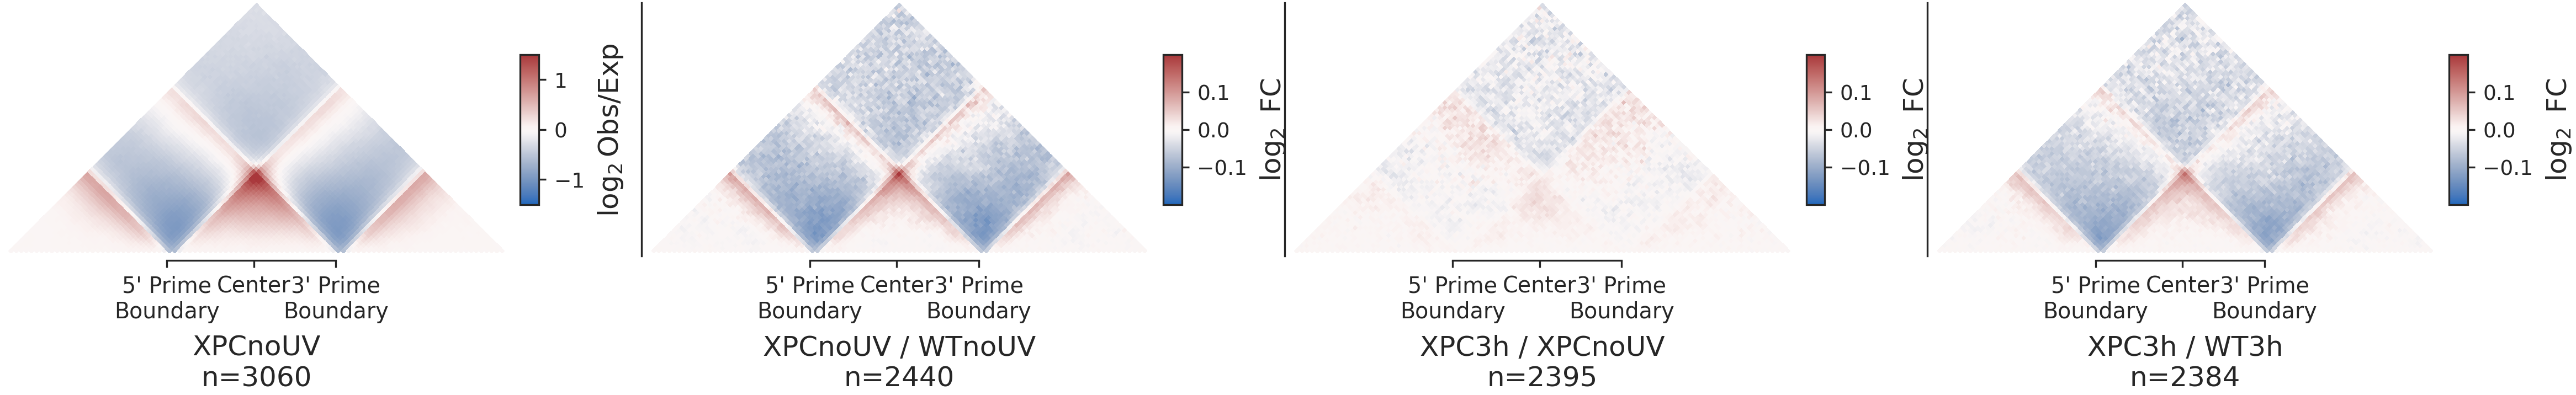

In [18]:
# xpc related comparisons converted to log2 fold-change (L2FC)
# base panel = Obs/Exp, comparison panels = log2(sample2 / sample1)

current_base_sample = 'XPCnoUV'
tup_idx_to_plot = [0, 1, 2]

eps = 1e-6

all_l2fc = []
for i in tup_idx_to_plot:
    s1, s2 = pups_diffs_[i]
    m1 = s1['data'][0]
    m2 = s2['data'][0]
    l2fc_mtx = np.log2((m2 + eps) / (m1 + eps))
    all_l2fc.append(l2fc_mtx)

# shared symmetric limits across all comparison heatmaps
all_vals = np.concatenate([mtx[np.isfinite(mtx)].ravel() for mtx in all_l2fc])
lim = np.max(np.abs(all_vals))
shared_vmin, shared_vmax = -lim, lim

aspect_ratio = 4.8
n_cols = len(tup_idx_to_plot) + 1
fig, axs = plt.subplots(1, n_cols, figsize=(n_cols * aspect_ratio, 1 * aspect_ratio))
plotting.update_rcparams()

# base heatmap stays as Obs/Exp
base_mtx = base_samples_data[current_base_sample]['data'][0]

ax = plotting.hic_upper_triangle(
    np.log2(base_mtx),
    cmap="vlag",
    center=0,
    ax=axs[0],
    colorbar=True,
    vmin=-1.5, vmax=1.5,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)

n = base_mtx.shape[0]
n_bins_rescaled = 99
fiveprime_bin = int(n_bins_rescaled * 0.33)
threeprime_bin = int(n_bins_rescaled * 0.66)
center_bin = int(n_bins_rescaled * 0.5)
bins = np.array([fiveprime_bin, center_bin, threeprime_bin])

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticks(
    2 * bins,
    labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
)
ax.set_xlabel(f"{current_base_sample}\nn={base_samples_data[current_base_sample].n[0]}", labelpad=5)
ax.tick_params(axis='x', labelsize=9.5)
ax.set_yticks([])

cbar = ax.figure.axes[-1]
cbar.set_ylabel(r"$\log_{2}$Obs/Exp", labelpad=5)

plotting.despine(ax)

for plot_idx, i in enumerate(tup_idx_to_plot):
    s1_name, s2_name = comparisons_tups[i]
    current_l2fc_mtx = all_l2fc[plot_idx]

    ax = plotting.hic_upper_triangle(
        current_l2fc_mtx,
        cmap="vlag",
        center=0,
        vmin=shared_vmin,
        vmax=shared_vmax,
        ax=axs[plot_idx + 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = current_l2fc_mtx.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"{s2_name} / {s1_name}\nn={pups_diffs_[i][0]['n'][0]}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$ FC", labelpad=5)

    plotting.despine(ax)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/xpc_tads_l2fc.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/xpc_tads_l2fc.svg', bbox_inches='tight')

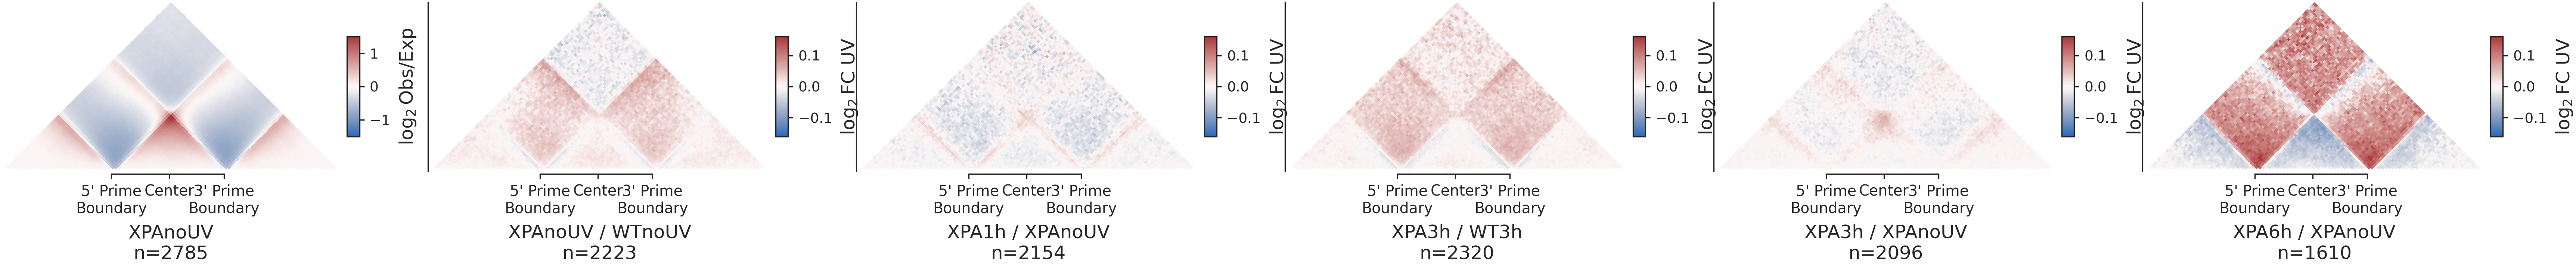

In [19]:
# xpa related comparisons converted to log2 fold-change (L2FC)
# base panel = Obs/Exp, comparison panels = log2(sample2 / sample1)

current_base_sample = 'XPAnoUV'
tup_idx_to_plot = [3, 4, 5, 6, 7]

eps = 1e-6

all_l2fc = []
for i in tup_idx_to_plot:
    s1, s2 = pups_diffs_[i]
    m1 = s1['data'][0]
    m2 = s2['data'][0]
    l2fc_mtx = np.log2((m2 + eps) / (m1 + eps))
    all_l2fc.append(l2fc_mtx)

# shared symmetric limits across all comparison heatmaps
all_vals = np.concatenate([mtx[np.isfinite(mtx)].ravel() for mtx in all_l2fc])
lim = np.max(np.abs(all_vals))
shared_vmin, shared_vmax = -lim, lim

aspect_ratio = 4.8
n_cols = len(tup_idx_to_plot) + 1
fig, axs = plt.subplots(1, n_cols, figsize=(n_cols * aspect_ratio, 1 * aspect_ratio))
plotting.update_rcparams()

# base heatmap stays as Obs/Exp
base_mtx = base_samples_data[current_base_sample]['data'][0]

ax = plotting.hic_upper_triangle(
    np.log2(base_mtx),
    cmap="vlag",
    center=0,
    ax=axs[0],
    colorbar=True,
    vmin=-1.5, vmax=1.5,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)

n = base_mtx.shape[0]
n_bins_rescaled = 99
fiveprime_bin = int(n_bins_rescaled * 0.33)
threeprime_bin = int(n_bins_rescaled * 0.66)
center_bin = int(n_bins_rescaled * 0.5)
bins = np.array([fiveprime_bin, center_bin, threeprime_bin])

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticks(
    2 * bins,
    labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
)
ax.set_xlabel(f"{current_base_sample}\nn={base_samples_data[current_base_sample].n[0]}", labelpad=5)
ax.tick_params(axis='x', labelsize=9.5)
ax.set_yticks([])

cbar = ax.figure.axes[-1]
cbar.set_ylabel(r"$\log_{2}$Obs/Exp", labelpad=5)

plotting.despine(ax)

for plot_idx, comp_idx in enumerate(tup_idx_to_plot):
    s1_name, s2_name = comparisons_tups[comp_idx]
    current_l2fc_mtx = all_l2fc[plot_idx]

    ax = plotting.hic_upper_triangle(
        current_l2fc_mtx,
        cmap="vlag",
        center=0,
        vmin=shared_vmin,
        vmax=shared_vmax,
        ax=axs[plot_idx + 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = current_l2fc_mtx.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"{s2_name} / {s1_name}\nn={pups_diffs_[comp_idx][0]['n'][0]}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC UV", labelpad=5)

    plotting.despine(ax)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/xpa_tads.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/xpa_tads.svg', bbox_inches='tight')

### loop&anchor counts

In [28]:
dots_dfs_ = [
    pd.read_csv(f'/home/carlos/Clone/ggner-3d/data/dots/dots_{s}_{bin_bp}.csv') for s in all_samples
]

apa_flank = 100_000

Anchors counts: [15293, 2686, 5845]
Loops counts: [11949, 2672, 6625]
Anchors counts: [15897, 2483, 5972]
Loops counts: [12732, 2321, 7034]


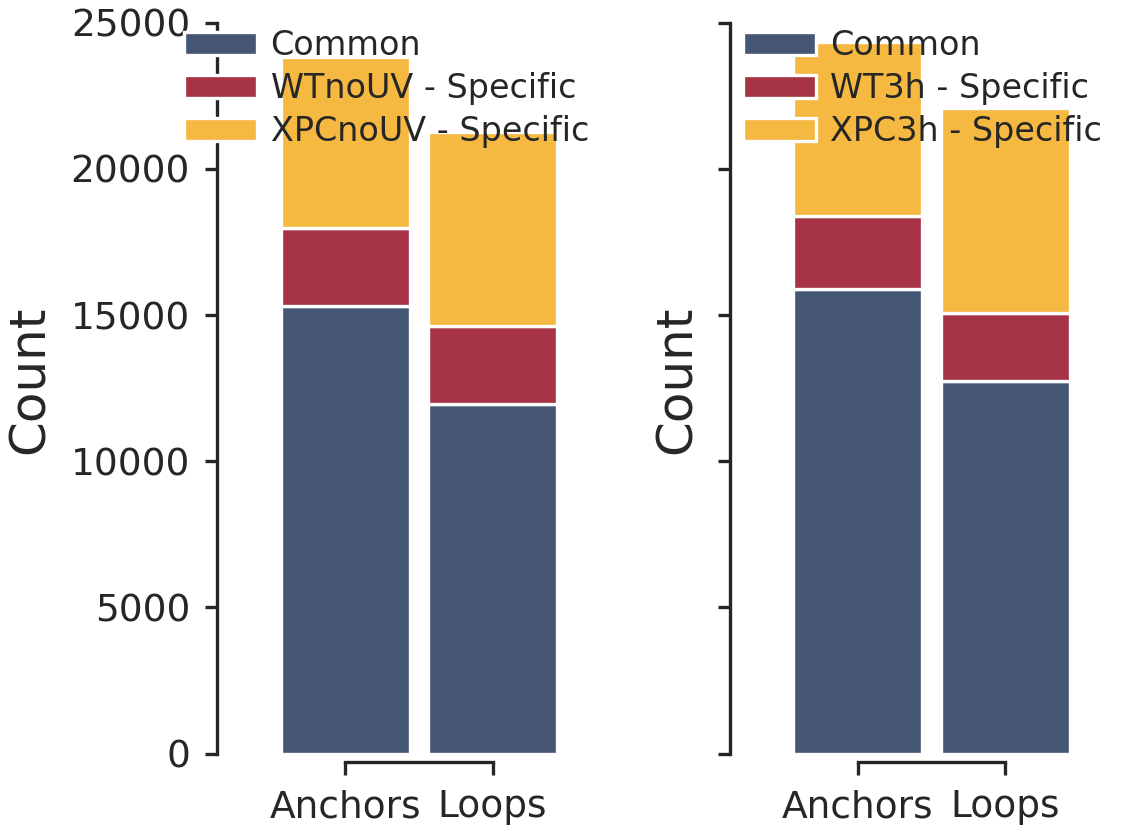

In [29]:
fig, axs = plt.subplots(1,2, figsize=(4, 3), sharey=True)
plotting.update_rcparams()

for i, (s1, s2) in enumerate([('WTnoUV', 'XPCnoUV'), ('WT3h', 'XPC3h')]):
    plot_anchor_loop_counts(
        s1=s1,
        s2=s2,
        clr_=clr_,
        dots_dfs_=dots_dfs_,
    clustering_radius=clustering_radius,
    plotting=plotting,
    compute_strength=False,
    ax=axs[i]
)
    
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/anchor_loop_counts_xpc_wt.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/anchor_loop_counts_xpc_wt.svg', bbox_inches='tight')

Anchors counts: [14678, 3301, 4260]
Loops counts: [11441, 3180, 5675]
Anchors counts: [15089, 3291, 3667]
Loops counts: [11867, 3186, 4506]


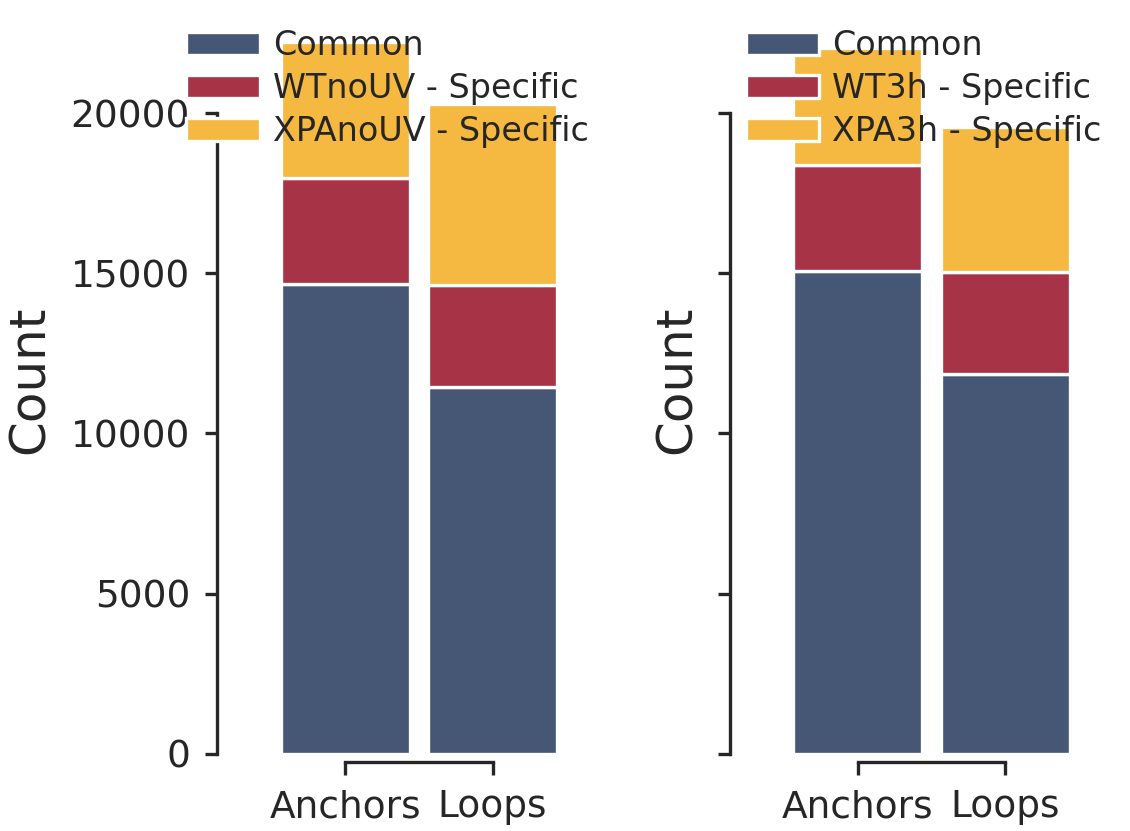

In [30]:
fig, axs = plt.subplots(1,2, figsize=(4, 3), sharey=True)
plotting.update_rcparams()

for i, (s1, s2) in enumerate([('WTnoUV', 'XPAnoUV'), ('WT3h', 'XPA3h')]):
    plot_anchor_loop_counts(
        s1=s1,
        s2=s2,
        clr_=clr_,
        dots_dfs_=dots_dfs_,
    clustering_radius=clustering_radius,
    plotting=plotting,
    compute_strength=False,
    ax=axs[i]
)
    
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/anchor_loop_counts_xpa_wt.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/anchor_loop_counts_xpa_wt.svg', bbox_inches='tight')

Anchors counts: [15487, 3451, 5651]
Loops counts: [12503, 4613, 6071]
Anchors counts: [15896, 2860, 5973]
Loops counts: [13034, 3339, 6732]


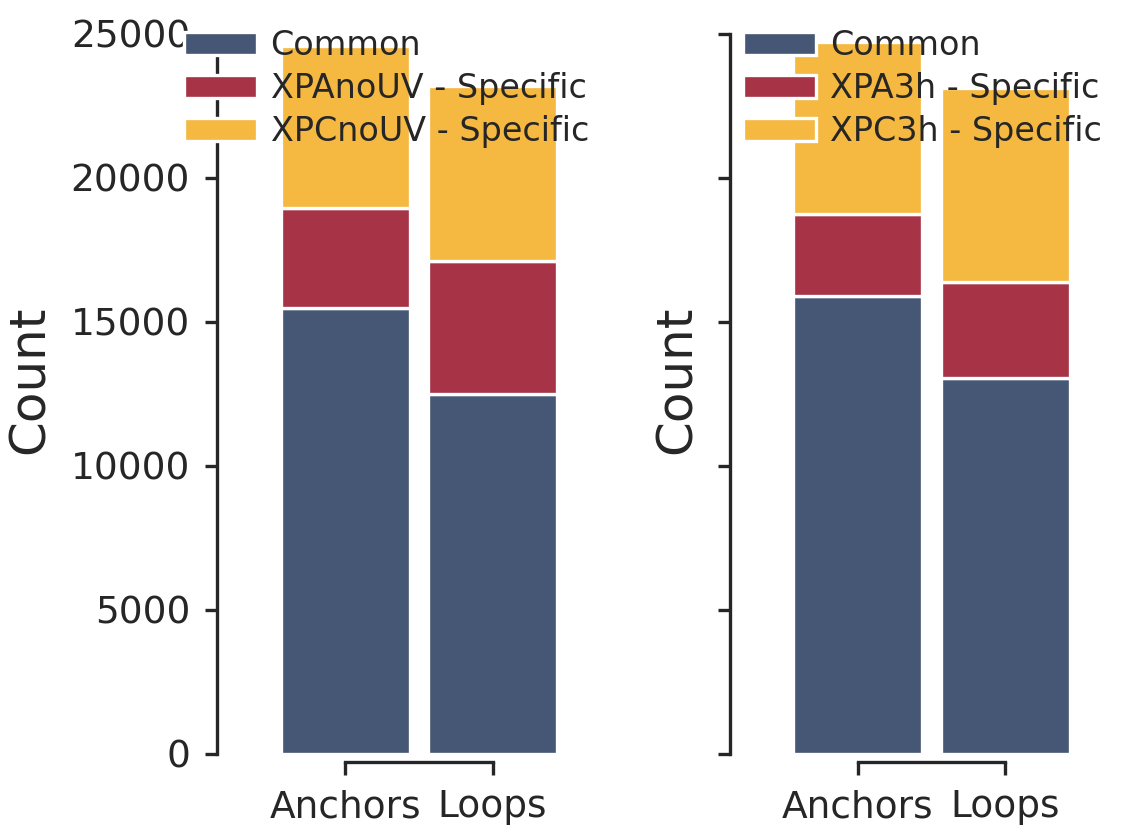

In [31]:
fig, axs = plt.subplots(1,2, figsize=(4, 3), sharey=True)
plotting.update_rcparams()

for i, (s1, s2) in enumerate([('XPAnoUV', 'XPCnoUV'), ('XPA3h', 'XPC3h')]):
    plot_anchor_loop_counts(
        s1=s1,
        s2=s2,
        clr_=clr_,
        dots_dfs_=dots_dfs_,
    clustering_radius=clustering_radius,
    plotting=plotting,
    compute_strength=False,
    ax=axs[i]
)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/anchor_loop_counts_xpa_xpc.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/anchor_loop_counts_xpa_xpc.svg', bbox_inches='tight')

### loops aggegated

In [32]:
base_samples_ = ['WTnoUV', 'XPCnoUV', 'XPAnoUV']
base_samples_data = {}
for base_sample in base_samples_:
    print(f"Processing sample: {base_sample}")
    sample_i = list(clr_.keys()).index(base_sample)
    current_loops = dots_dfs_[sample_i]

    clr = clr_[base_sample]
    expected = get_expected_cis_df(base_sample, resolution_kb=bin_bp//1000, label='chrom')
    view_df = prepare_view_df(arm=False)

    pup = coolpup.pileup(clr, current_loops, features_format='bedpe', view_df=view_df, expected_df=expected, flank=apa_flank, nproc=6, local=False, clr_weight_name=WEIGHT)
    base_samples_data[base_sample] = pup

Processing sample: WTnoUV


INFO:coolpuppy:('chr4', 'chr4'): 688
INFO:coolpuppy:('chr5', 'chr5'): 743
INFO:coolpuppy:('chr6', 'chr6'): 700
INFO:coolpuppy:('chr3', 'chr3'): 767
INFO:coolpuppy:('chr1', 'chr1'): 981
INFO:coolpuppy:('chr2', 'chr2'): 1079
INFO:coolpuppy:('chr9', 'chr9'): 445
INFO:coolpuppy:('chr7', 'chr7'): 629
INFO:coolpuppy:('chr10', 'chr10'): 644
INFO:coolpuppy:('chr13', 'chr13'): 266
INFO:coolpuppy:('chr12', 'chr12'): 573
INFO:coolpuppy:('chr8', 'chr8'): 747
INFO:coolpuppy:('chr11', 'chr11'): 564
INFO:coolpuppy:('chr14', 'chr14'): 379
INFO:coolpuppy:('chr15', 'chr15'): 398
INFO:coolpuppy:('chr16', 'chr16'): 251
INFO:coolpuppy:('chr21', 'chr21'): 124
INFO:coolpuppy:('chr19', 'chr19'): 178
INFO:coolpuppy:('chr17', 'chr17'): 294
INFO:coolpuppy:('chr22', 'chr22'): 194
INFO:coolpuppy:('chr20', 'chr20'): 300
INFO:coolpuppy:('chr18', 'chr18'): 274
INFO:coolpuppy:('chrX', 'chrX'): 201
INFO:coolpuppy:Total number of piled up windows: 11419


Processing sample: XPCnoUV


INFO:coolpuppy:('chr5', 'chr5'): 985
INFO:coolpuppy:('chr6', 'chr6'): 889
INFO:coolpuppy:('chr3', 'chr3'): 1008
INFO:coolpuppy:('chr4', 'chr4'): 928
INFO:coolpuppy:('chr1', 'chr1'): 1220
INFO:coolpuppy:('chr2', 'chr2'): 1428
INFO:coolpuppy:('chr9', 'chr9'): 439
INFO:coolpuppy:('chr10', 'chr10'): 763
INFO:coolpuppy:('chr7', 'chr7'): 835
INFO:coolpuppy:('chr11', 'chr11'): 717
INFO:coolpuppy:('chr13', 'chr13'): 352
INFO:coolpuppy:('chr8', 'chr8'): 977
INFO:coolpuppy:('chr12', 'chr12'): 717
INFO:coolpuppy:('chr14', 'chr14'): 396
INFO:coolpuppy:('chr16', 'chr16'): 355
INFO:coolpuppy:('chr15', 'chr15'): 464
INFO:coolpuppy:('chr17', 'chr17'): 410
INFO:coolpuppy:('chr19', 'chr19'): 243
INFO:coolpuppy:('chr21', 'chr21'): 177
INFO:coolpuppy:('chr18', 'chr18'): 342
INFO:coolpuppy:('chr22', 'chr22'): 214
INFO:coolpuppy:('chr20', 'chr20'): 399
INFO:coolpuppy:('chrX', 'chrX'): 307
INFO:coolpuppy:Total number of piled up windows: 14565


Processing sample: XPAnoUV


INFO:coolpuppy:('chr4', 'chr4'): 861
INFO:coolpuppy:('chr5', 'chr5'): 860
INFO:coolpuppy:('chr6', 'chr6'): 909
INFO:coolpuppy:('chr3', 'chr3'): 926
INFO:coolpuppy:('chr1', 'chr1'): 1177
INFO:coolpuppy:('chr2', 'chr2'): 1324
INFO:coolpuppy:('chr9', 'chr9'): 545
INFO:coolpuppy:('chr7', 'chr7'): 798
INFO:coolpuppy:('chr10', 'chr10'): 761
INFO:coolpuppy:('chr11', 'chr11'): 664
INFO:coolpuppy:('chr13', 'chr13'): 334
INFO:coolpuppy:('chr8', 'chr8'): 916
INFO:coolpuppy:('chr12', 'chr12'): 685
INFO:coolpuppy:('chr14', 'chr14'): 458
INFO:coolpuppy:('chr16', 'chr16'): 326
INFO:coolpuppy:('chr17', 'chr17'): 367
INFO:coolpuppy:('chr19', 'chr19'): 263
INFO:coolpuppy:('chr18', 'chr18'): 307
INFO:coolpuppy:('chr15', 'chr15'): 482
INFO:coolpuppy:('chr21', 'chr21'): 156
INFO:coolpuppy:('chr22', 'chr22'): 200
INFO:coolpuppy:('chr20', 'chr20'): 371
INFO:coolpuppy:('chrX', 'chrX'): 256
INFO:coolpuppy:Total number of piled up windows: 13946


In [33]:
dots_tups = [
    ('WTnoUV', 'XPCnoUV'),
    ('WT3h', 'XPC3h'),
    ('WTnoUV', 'XPAnoUV'),
    ('WT3h', 'XPA3h'),
    ('XPAnoUV', 'XPCnoUV'),
    ('XPA3h', 'XPC3h')
]

from ggner_3d.loop_helpers import format_loops_columns

dots_pups_data = {}
for i, (s1, s2) in enumerate(dots_tups):
    print(f"Comparing {s1} vs {s2}")
    s1_index = all_samples.index(s1)
    s2_index = all_samples.index(s2)
    df_a = dots_dfs_[s1_index]
    df_b = dots_dfs_[s2_index]

    res = compare_loops_with_strength(
        df_a=df_a,
        df_b=df_b,
        clustering_radius=clustering_radius,
        compute_strength=False
    )

    common_loops = res['common_loops']
    common_loops = format_loops_columns(common_loops)

    clr1 = clr_[s1]
    clr2 = clr_[s2]
    expected1 = get_expected_cis_df(s1, resolution_kb=bin_bp//1000, label='arm')
    expected2 = get_expected_cis_df(s2, resolution_kb=bin_bp//1000, label='arm')
    view_df = prepare_view_df(arm=True)

    pup1 = coolpup.pileup(clr1, common_loops, features_format='bedpe', view_df=view_df, expected_df=expected1, flank=apa_flank, nproc=6, local=False, clr_weight_name=WEIGHT)
    pup2 = coolpup.pileup(clr2, common_loops, features_format='bedpe', view_df=view_df, expected_df=expected2, flank=apa_flank, nproc=6, local=False, clr_weight_name=WEIGHT)
    
    dots_pups_data[(s1, s2)] = (pup1, pup2)

Comparing WTnoUV vs XPCnoUV


INFO:coolpuppy:('chr4_p', 'chr4_p'): 120
INFO:coolpuppy:('chr5_p', 'chr5_p'): 146
INFO:coolpuppy:('chr6_p', 'chr6_p'): 233
INFO:coolpuppy:('chr3_p', 'chr3_p'): 254
INFO:coolpuppy:('chr2_p', 'chr2_p'): 355
INFO:coolpuppy:('chr1_p', 'chr1_p'): 416
INFO:coolpuppy:('chr6_q', 'chr6_q'): 344
INFO:coolpuppy:('chr5_q', 'chr5_q'): 462
INFO:coolpuppy:('chr4_q', 'chr4_q'): 441
INFO:coolpuppy:('chr3_q', 'chr3_q'): 391
INFO:coolpuppy:('chr1_q', 'chr1_q'): 371
INFO:coolpuppy:('chr8_p', 'chr8_p'): 159
INFO:coolpuppy:('chr9_p', 'chr9_p'): 119
INFO:coolpuppy:('chr10_p', 'chr10_p'): 140
INFO:coolpuppy:('chr7_p', 'chr7_p'): 278
INFO:coolpuppy:('chr11_p', 'chr11_p'): 198
INFO:coolpuppy:('chr2_q', 'chr2_q'): 540
INFO:coolpuppy:('chr9_q', 'chr9_q'): 205
INFO:coolpuppy:('chr12_p', 'chr12_p'): 135
INFO:coolpuppy:('chr10_q', 'chr10_q'): 360
INFO:coolpuppy:('chr7_q', 'chr7_q'): 248
INFO:coolpuppy:('chr11_q', 'chr11_q'): 276
INFO:coolpuppy:('chr13_q', 'chr13_q'): 220
INFO:coolpuppy:('chr16_p', 'chr16_p'): 72
INF

Comparing WT3h vs XPC3h


INFO:coolpuppy:('chr4_p', 'chr4_p'): 128
INFO:coolpuppy:('chr5_p', 'chr5_p'): 159
INFO:coolpuppy:('chr3_p', 'chr3_p'): 287
INFO:coolpuppy:('chr6_p', 'chr6_p'): 239
INFO:coolpuppy:('chr2_p', 'chr2_p'): 380
INFO:coolpuppy:('chr1_p', 'chr1_p'): 454
INFO:coolpuppy:('chr4_q', 'chr4_q'): 439
INFO:coolpuppy:('chr6_q', 'chr6_q'): 376
INFO:coolpuppy:('chr3_q', 'chr3_q'): 418
INFO:coolpuppy:('chr5_q', 'chr5_q'): 469
INFO:coolpuppy:('chr1_q', 'chr1_q'): 408
INFO:coolpuppy:('chr8_p', 'chr8_p'): 165
INFO:coolpuppy:('chr9_p', 'chr9_p'): 120
INFO:coolpuppy:('chr10_p', 'chr10_p'): 141
INFO:coolpuppy:('chr7_p', 'chr7_p'): 292
INFO:coolpuppy:('chr2_q', 'chr2_q'): 565
INFO:coolpuppy:('chr11_p', 'chr11_p'): 209
INFO:coolpuppy:('chr9_q', 'chr9_q'): 210
INFO:coolpuppy:('chr12_p', 'chr12_p'): 161
INFO:coolpuppy:('chr7_q', 'chr7_q'): 251
INFO:coolpuppy:('chr11_q', 'chr11_q'): 282
INFO:coolpuppy:('chr10_q', 'chr10_q'): 364
INFO:coolpuppy:('chr12_q', 'chr12_q'): 331
INFO:coolpuppy:('chr16_p', 'chr16_p'): 81
INF

Comparing WTnoUV vs XPAnoUV


...

INFO:coolpuppy:('chr4_p', 'chr4_p'): 122
INFO:coolpuppy:('chr5_p', 'chr5_p'): 144
INFO:coolpuppy:('chr3_p', 'chr3_p'): 250
INFO:coolpuppy:('chr6_p', 'chr6_p'): 237
INFO:coolpuppy:('chr2_p', 'chr2_p'): 359
INFO:coolpuppy:('chr1_p', 'chr1_p'): 413
INFO:coolpuppy:('chr4_q', 'chr4_q'): 397
INFO:coolpuppy:('chr6_q', 'chr6_q'): 339
INFO:coolpuppy:('chr5_q', 'chr5_q'): 439
INFO:coolpuppy:('chr3_q', 'chr3_q'): 391
INFO:coolpuppy:('chr1_q', 'chr1_q'): 370
INFO:coolpuppy:('chr8_p', 'chr8_p'): 155
INFO:coolpuppy:('chr9_p', 'chr9_p'): 113
INFO:coolpuppy:('chr10_p', 'chr10_p'): 138
INFO:coolpuppy:('chr7_p', 'chr7_p'): 280
INFO:coolpuppy:('chr11_p', 'chr11_p'): 189
INFO:coolpuppy:('chr2_q', 'chr2_q'): 526
INFO:coolpuppy:('chr9_q', 'chr9_q'): 248
INFO:coolpuppy:('chr12_p', 'chr12_p'): 144
INFO:coolpuppy:('chr7_q', 'chr7_q'): 234
INFO:coolpuppy:('chr10_q', 'chr10_q'): 342
INFO:coolpuppy:('chr11_q', 'chr11_q'): 274
INFO:coolpuppy:('chr8_q', 'chr8_q'): 460
INFO:coolpuppy:('chr13_q', 'chr13_q'): 202
INFO

Comparing XPAnoUV vs XPCnoUV


INFO:coolpuppy:('chr4_p', 'chr4_p'): 146
INFO:coolpuppy:('chr5_p', 'chr5_p'): 151
INFO:coolpuppy:('chr3_p', 'chr3_p'): 283
INFO:coolpuppy:('chr6_p', 'chr6_p'): 254
INFO:coolpuppy:('chr2_p', 'chr2_p'): 386
INFO:coolpuppy:('chr1_p', 'chr1_p'): 436
INFO:coolpuppy:('chr4_q', 'chr4_q'): 479
INFO:coolpuppy:('chr5_q', 'chr5_q'): 497
INFO:coolpuppy:('chr6_q', 'chr6_q'): 364
INFO:coolpuppy:('chr3_q', 'chr3_q'): 418
INFO:coolpuppy:('chr1_q', 'chr1_q'): 424
INFO:coolpuppy:('chr9_p', 'chr9_p'): 124
INFO:coolpuppy:('chr8_p', 'chr8_p'): 176
INFO:coolpuppy:('chr10_p', 'chr10_p'): 149
INFO:coolpuppy:('chr7_p', 'chr7_p'): 323
INFO:coolpuppy:('chr11_p', 'chr11_p'): 206
INFO:coolpuppy:('chr2_q', 'chr2_q'): 594
INFO:coolpuppy:('chr9_q', 'chr9_q'): 223
INFO:coolpuppy:('chr12_p', 'chr12_p'): 136
INFO:coolpuppy:('chr11_q', 'chr11_q'): 291
INFO:coolpuppy:('chr7_q', 'chr7_q'): 261
INFO:coolpuppy:('chr10_q', 'chr10_q'): 378
INFO:coolpuppy:('chr16_p', 'chr16_p'): 78
INFO:coolpuppy:('chr8_q', 'chr8_q'): 493
INFO:

Comparing XPA3h vs XPC3h


INFO:coolpuppy:('chr4_p', 'chr4_p'): 145
INFO:coolpuppy:('chr5_p', 'chr5_p'): 158
INFO:coolpuppy:('chr3_p', 'chr3_p'): 282
INFO:coolpuppy:('chr6_p', 'chr6_p'): 278
INFO:coolpuppy:('chr2_p', 'chr2_p'): 425
INFO:coolpuppy:('chr1_p', 'chr1_p'): 460
INFO:coolpuppy:('chr5_q', 'chr5_q'): 484
INFO:coolpuppy:('chr6_q', 'chr6_q'): 375
INFO:coolpuppy:('chr4_q', 'chr4_q'): 464
INFO:coolpuppy:('chr3_q', 'chr3_q'): 447
INFO:coolpuppy:('chr1_q', 'chr1_q'): 428
INFO:coolpuppy:('chr8_p', 'chr8_p'): 187
INFO:coolpuppy:('chr9_p', 'chr9_p'): 128
INFO:coolpuppy:('chr10_p', 'chr10_p'): 145
INFO:coolpuppy:('chr7_p', 'chr7_p'): 324
INFO:coolpuppy:('chr11_p', 'chr11_p'): 212
INFO:coolpuppy:('chr2_q', 'chr2_q'): 570
INFO:coolpuppy:('chr9_q', 'chr9_q'): 230
INFO:coolpuppy:('chr12_p', 'chr12_p'): 160
INFO:coolpuppy:('chr11_q', 'chr11_q'): 296
INFO:coolpuppy:('chr10_q', 'chr10_q'): 393
INFO:coolpuppy:('chr7_q', 'chr7_q'): 266
INFO:coolpuppy:('chr13_q', 'chr13_q'): 224
INFO:coolpuppy:('chr8_q', 'chr8_q'): 510
INFO

In [55]:
from matplotlib import patches

def loop_strength_corner_size(mtx_size):
    return int(np.ceil(0.3 * mtx_size) // 2 * 2 + 1)

def add_scores(scores_type, score_, ax, mtx_size, corner_size=None, font_scale=2, height=6):
    if corner_size is None:
        corner_size = loop_strength_corner_size(mtx_size)

    center_idx = mtx_size // 2
    center_size = 3
    center_start = center_idx - center_size // 2

    if scores_type == "central_score" or scores_type == "loop_strength":
        ax.text(
            s=f"{score_:.3g}",
            y=0.95,
            x=0.05,
            ha="left",
            va="top",
            size=font_scale * (4.94 + height),
            transform=ax.transAxes,
        )

    elif scores_type == "corner_scores":
        # central 3x3 patch
        ax.add_patch(
            patches.Rectangle(
                (center_start, center_start),
                center_size,
                center_size,
                linewidth=2,
                edgecolor="#465775",
                facecolor="none",
            )
        )

        # top left
        ax.text(
            s=f"{score_[0]:.3g}",
            y=0.95,
            x=0.05,
            ha="left",
            va="top",
            size=font_scale * (4.94 + height),
            transform=ax.transAxes,
        )
        ax.add_patch(
            patches.Rectangle((0, 0), corner_size, corner_size,
                              linewidth=2, edgecolor="#465775", facecolor="none")
        )

        # top right
        ax.text(
            s=f"{score_[1]:.3g}",
            y=0.95,
            x=0.95,
            ha="right",
            va="top",
            size=font_scale * (4.94 + height),
            transform=ax.transAxes,
        )
        ax.add_patch(
            patches.Rectangle((mtx_size - corner_size, 0), corner_size, corner_size,
                              linewidth=2, edgecolor="#465775", facecolor="none")
        )

        # bottom left
        ax.text(
            s=f"{score_[2]:.3g}",
            y=0.05,
            x=0.05,
            ha="left",
            va="bottom",
            size=font_scale * (4.94 + height),
            transform=ax.transAxes,
        )
        ax.add_patch(
            patches.Rectangle((0, mtx_size - corner_size), corner_size, corner_size,
                              linewidth=2, edgecolor="#465775", facecolor="none")
        )

        # bottom right
        ax.text(
            s=f"{score_[3]:.3g}",
            y=0.05,
            x=0.95,
            ha="right",
            va="bottom",
            size=font_scale * (4.94 + height),
            transform=ax.transAxes,
        )
        ax.add_patch(
            patches.Rectangle((mtx_size - corner_size, mtx_size - corner_size),
                              corner_size, corner_size,
                              linewidth=2, edgecolor="#465775", facecolor="none")
        )


def get_corner_scores(data):
    sq_size = data.shape[0]
    midpoint = int(np.floor(sq_size / 2))

    center = np.nanmean(
        data[midpoint - 1:midpoint + 2, midpoint - 1:midpoint + 2]
    )

    n_bins = int(np.ceil(0.3 * sq_size) // 2 * 2 + 1)

    tl = np.nanmean(data[:n_bins, :n_bins])
    tr = np.nanmean(data[:n_bins, sq_size - n_bins:])
    bl = np.nanmean(data[sq_size - n_bins:, :n_bins])
    br = np.nanmean(data[sq_size - n_bins:, sq_size - n_bins:])

    return [
        center / tl,
        center / tr,
        center / bl,
        center / br,
    ]


def central_score(data):
    return np.nanmean(data[9:12, 9:12])


def _quantify_loops(mtx):
        sq_size = mtx.shape[0]
        midpoint = int(np.floor(sq_size / 2))
        mid_9pixels_mean = np.nanmean(mtx[midpoint - 1:midpoint + 2, midpoint - 1:midpoint + 2])
        neighboring_size = int(np.ceil(0.3 * sq_size) // 2 * 2 + 1)
        upper_left_mean = np.nanmean(mtx[:neighboring_size, :neighboring_size])
        upper_right_mean = np.nanmean(mtx[:neighboring_size, (sq_size - neighboring_size):])
        lower_right_mean = np.nanmean(mtx[(sq_size - neighboring_size):, (sq_size - neighboring_size):])
        bg = np.nanmean(np.array([upper_left_mean, upper_right_mean, lower_right_mean]))
        return mid_9pixels_mean / bg

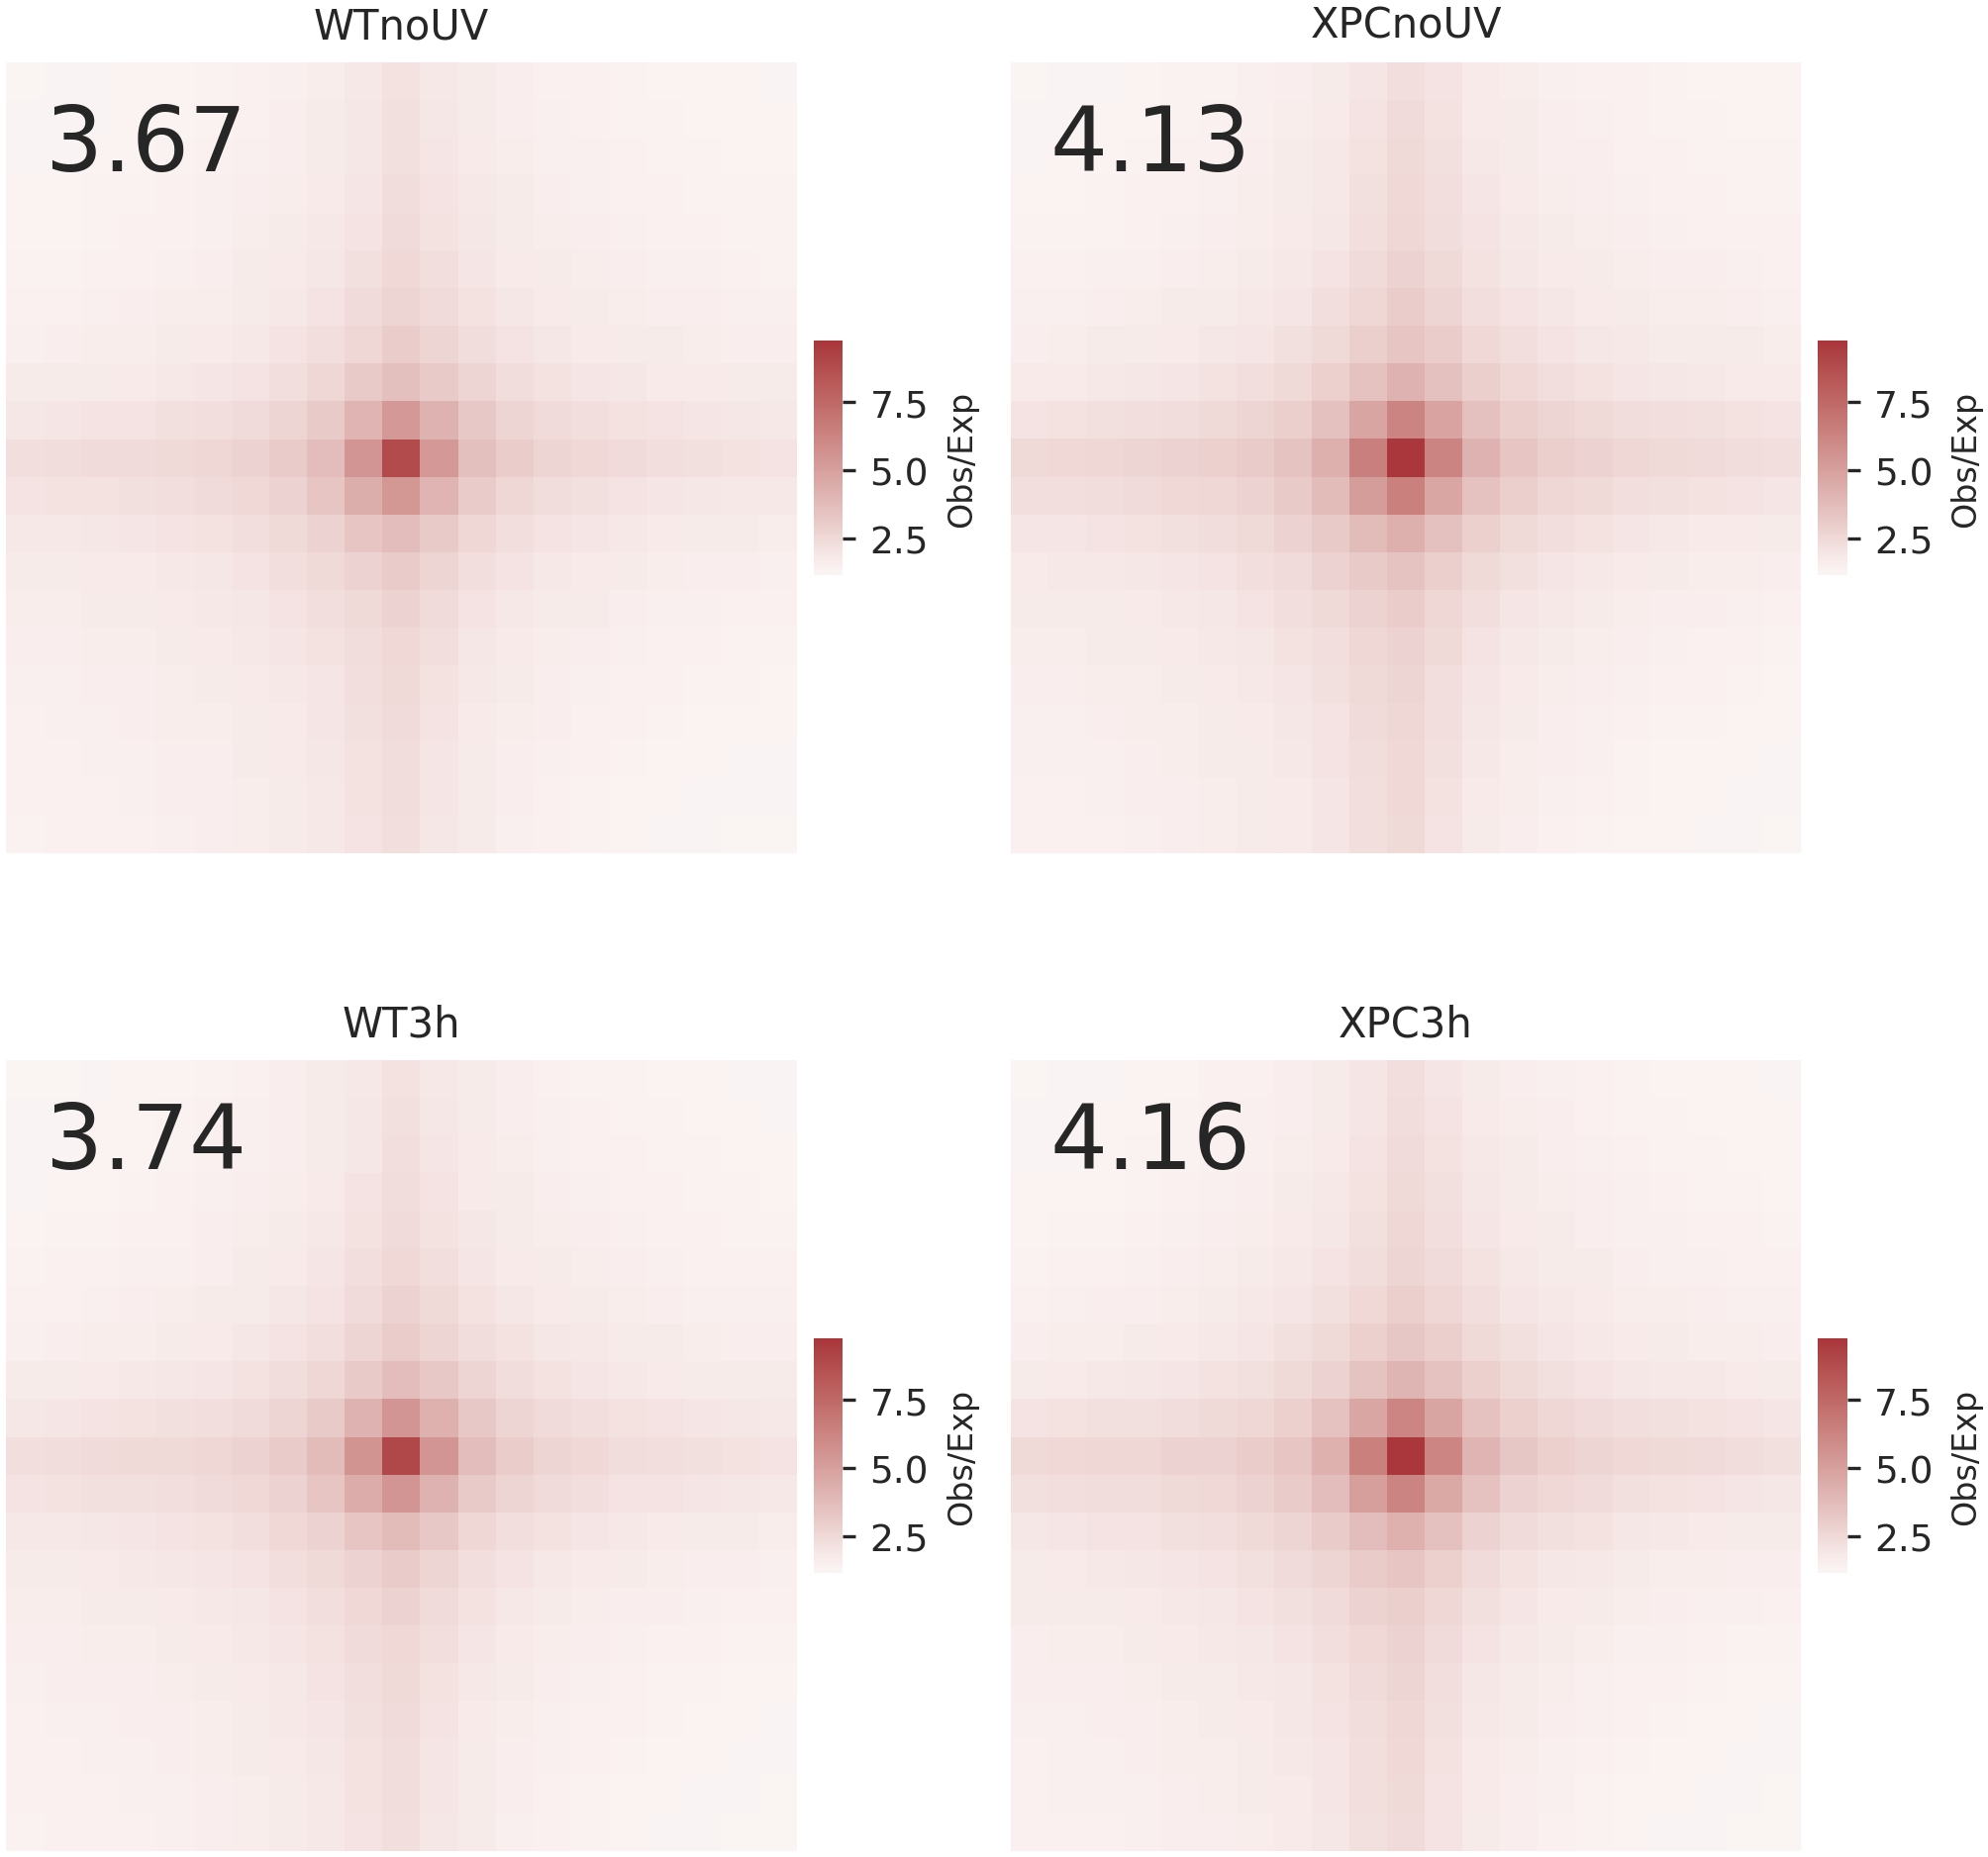

In [58]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
plotting.update_rcparams()

def heatmap_wrapper(mtx, ax, vmin=None, vmax=None):
    sns.heatmap(
        mtx,
        cmap="vlag",
        center=1,
        ax=ax,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8),
        square=True,
        xticklabels=False,
        yticklabels=False,
        vmin=vmin,
        vmax=vmax
    )

    cbar = ax.collections[0].colorbar
    cbar.set_label('Obs/Exp', fontsize=8)

wtnouv_pup, xpcnouv_pup = dots_pups_data[('WTnoUV', 'XPCnoUV')]
wt3h_pup, xpc3h_pup = dots_pups_data[('WT3h', 'XPC3h')]

for pup in [wtnouv_pup, xpcnouv_pup, wt3h_pup, xpc3h_pup]:
    pup['central_score'] = pup.apply(
                    lambda x: central_score(x['data']), axis=1
                )
    pup['corner_scores'] = pup.apply(
                    lambda x: get_corner_scores(x['data']), axis=1
                )
    pup['loop_strength'] = pup.apply(
                    lambda x: _quantify_loops(x['data']), axis=1
                )

vmin, vmax = np.nanmin([wtnouv_pup['data'][0], xpcnouv_pup['data'][0], wt3h_pup['data'][0], xpc3h_pup['data'][0]]), np.nanmax([wtnouv_pup['data'][0], xpcnouv_pup['data'][0], wt3h_pup['data'][0], xpc3h_pup['data'][0]])

score_type = "loop_strength" # "corner_scores" or "central_score" or "loop_strength"

heatmap_wrapper(wtnouv_pup['data'][0], axs[0,0], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpcnouv_pup['data'][0], axs[0,1], vmin=vmin, vmax=vmax)
heatmap_wrapper(wt3h_pup['data'][0], axs[1,0], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpc3h_pup['data'][0], axs[1,1], vmin=vmin, vmax=vmax)

# add titles
n_nouv = wtnouv_pup['n'][0]
n_3h = wt3h_pup['n'][0]
axs[0,0].set_title('WTnoUV', fontsize=10)
axs[0,1].set_title('XPCnoUV', fontsize=10)
axs[1,0].set_title('WT3h', fontsize=10)
axs[1,1].set_title('XPC3h', fontsize=10)

add_scores(score_type, wtnouv_pup[score_type][0], axs[0,0], wtnouv_pup['data'][0].shape[0])
add_scores(score_type, xpcnouv_pup[score_type][0], axs[0,1], xpcnouv_pup['data'][0].shape[0])
add_scores(score_type, wt3h_pup[score_type][0], axs[1,0], wt3h_pup['data'][0].shape[0])
add_scores(score_type, xpc3h_pup[score_type][0], axs[1,1], xpc3h_pup['data'][0].shape[0])

fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig3/xpc_loops_apa_scores_{score_type}.png', dpi=300, bbox_inches='tight')
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig3/xpc_loops_apa_scores_{score_type}.svg', bbox_inches='tight')

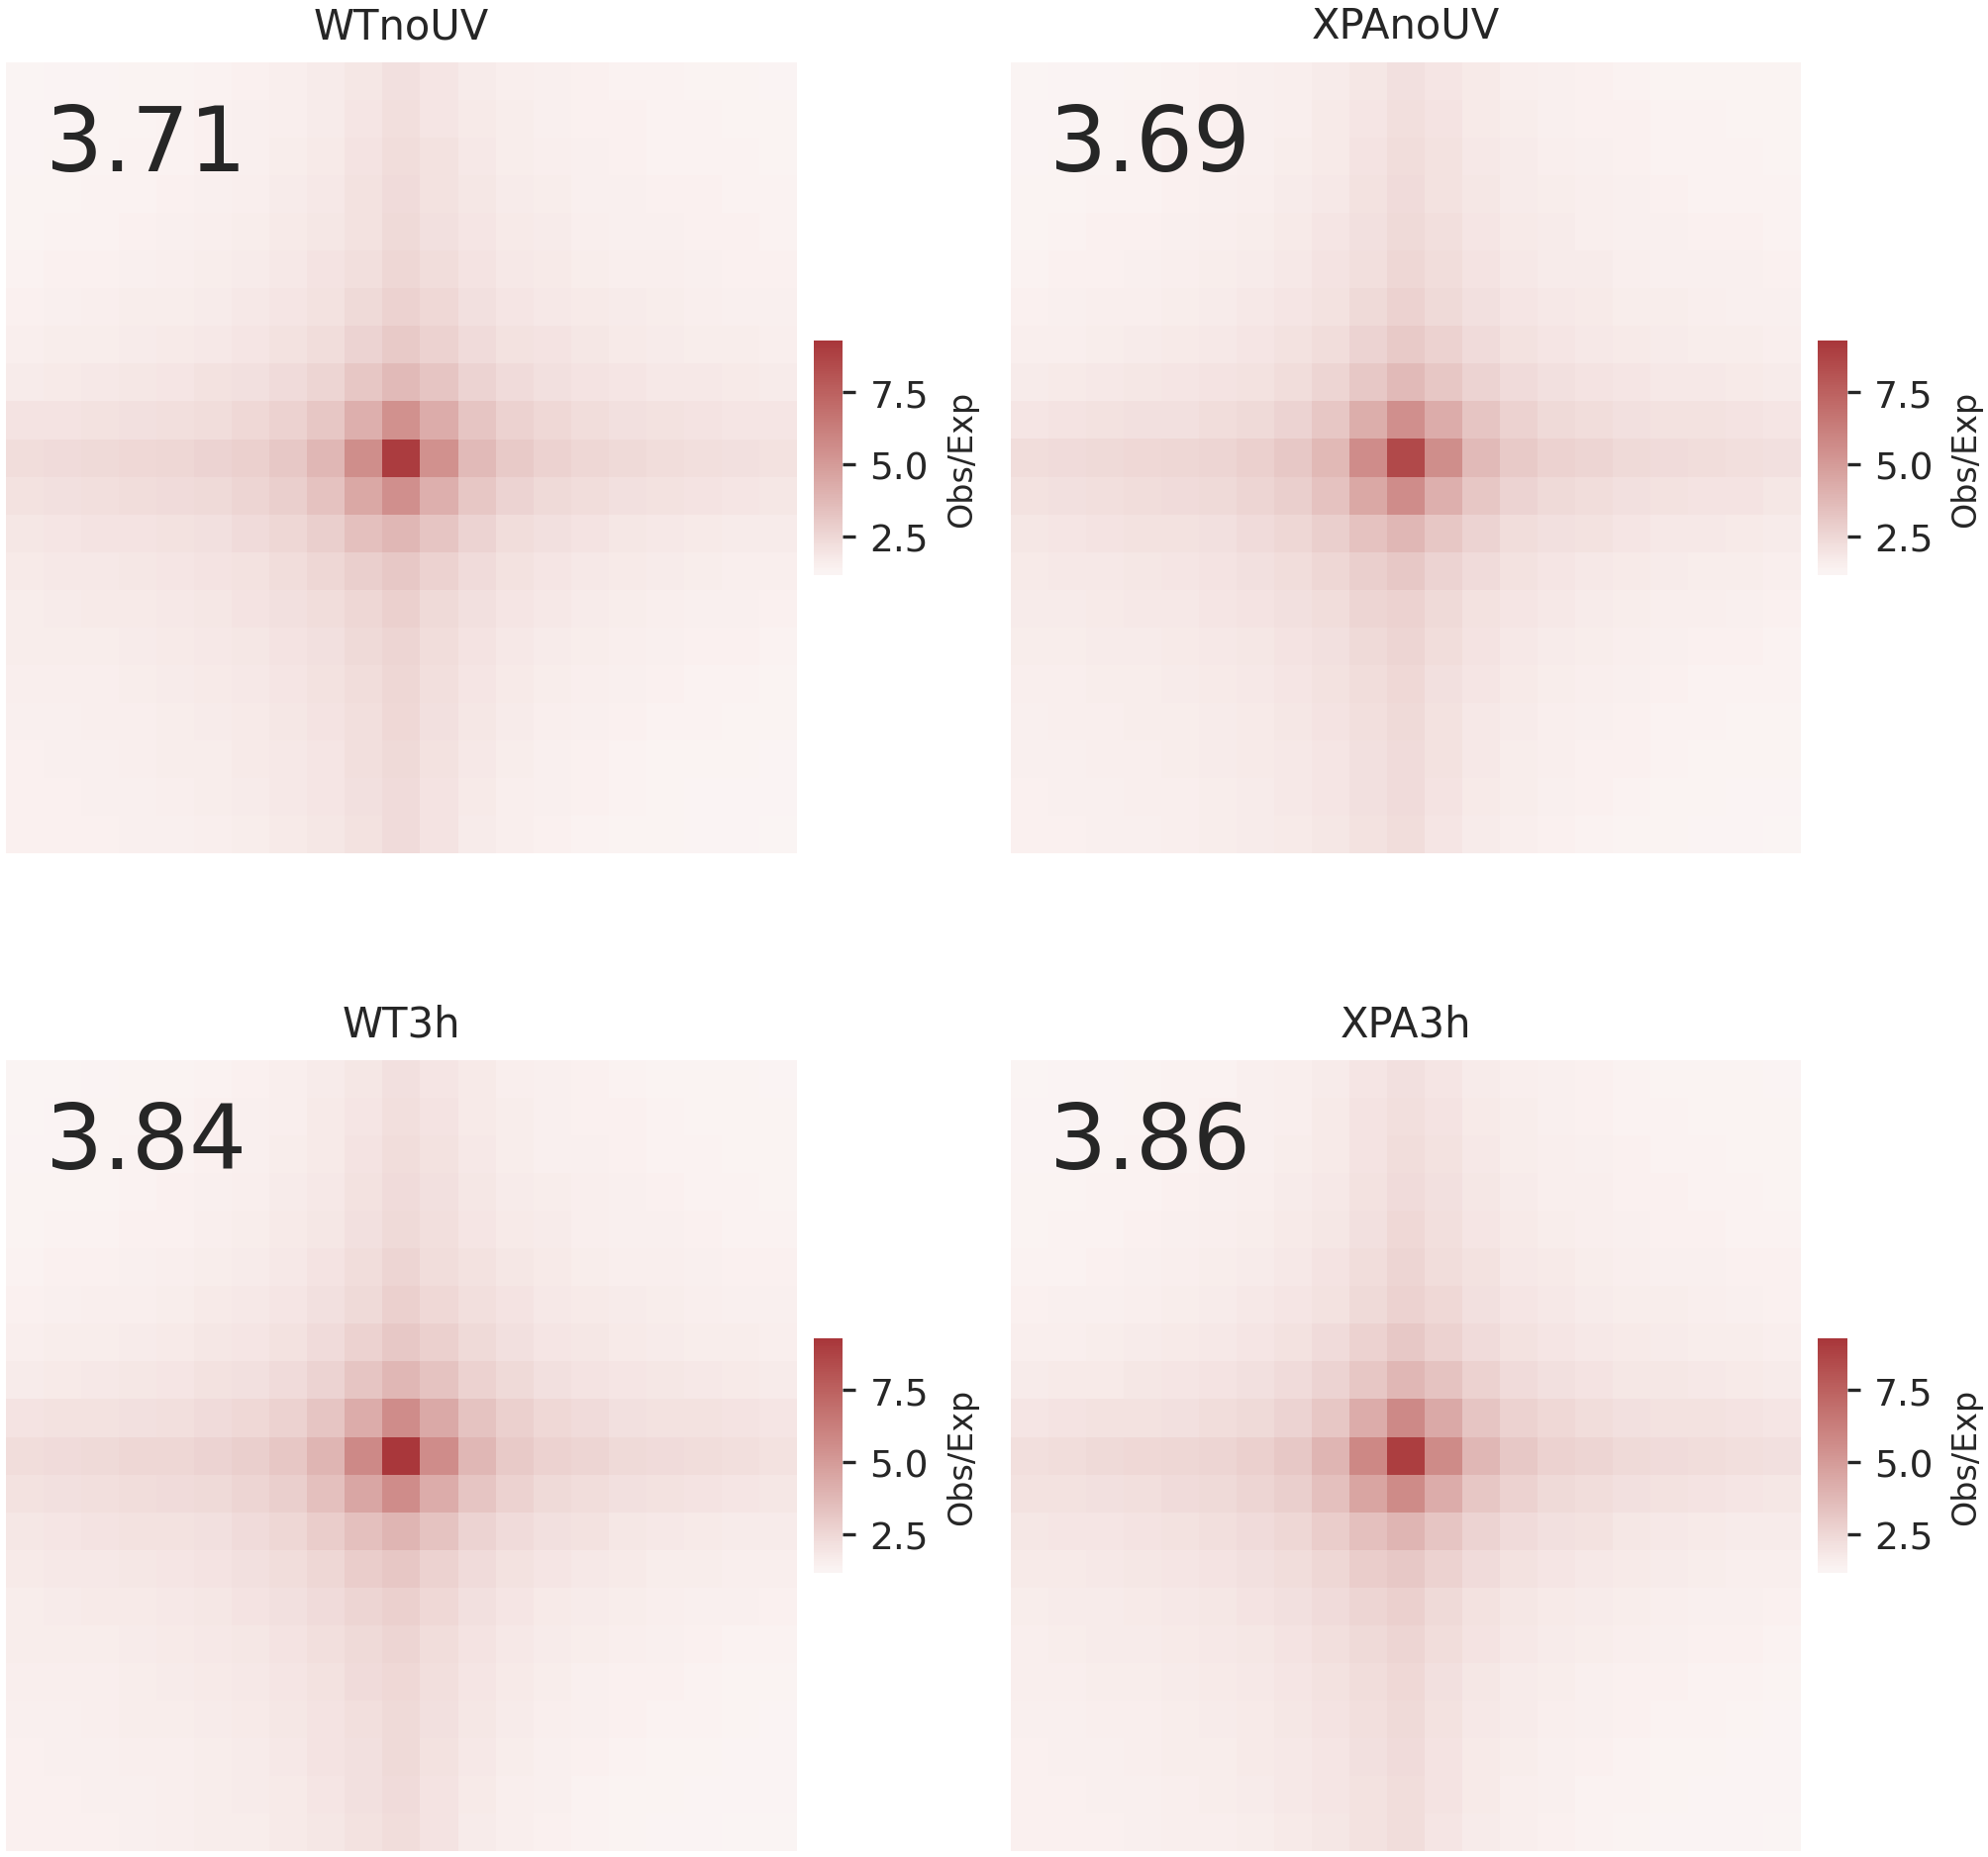

In [36]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
plotting.update_rcparams()

wtnouv_pup, xpanouv_pup = dots_pups_data[('WTnoUV', 'XPAnoUV')]
wt3h_pup, xpa3h_pup = dots_pups_data[('WT3h', 'XPA3h')]


central_size = 1

for pup in [wtnouv_pup, xpanouv_pup, wt3h_pup, xpa3h_pup]:
    pup['central_score'] = pup.apply(
                    lambda x: central_score(x['data'], central_size), axis=1
                )
    pup['corner_scores'] = pup.apply(
                    lambda x: get_corner_scores(x['data']), axis=1
                )
    pup['loop_strength'] = pup.apply(
                    lambda x: _quantify_loops(x['data']), axis=1
                )

vmin, vmax = np.nanmin([wtnouv_pup['data'][0], xpanouv_pup['data'][0], wt3h_pup['data'][0], xpa3h_pup['data'][0]]), np.nanmax([wtnouv_pup['data'][0], xpanouv_pup['data'][0], wt3h_pup['data'][0], xpa3h_pup['data'][0]])

score_type = "loop_strength" # "corner_scores" or "central_score"

heatmap_wrapper(wtnouv_pup['data'][0], axs[0,0], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpanouv_pup['data'][0], axs[0,1], vmin=vmin, vmax=vmax)
heatmap_wrapper(wt3h_pup['data'][0], axs[1,0], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpa3h_pup['data'][0], axs[1,1], vmin=vmin, vmax=vmax)

# add titles
n_nouv = wtnouv_pup['n'][0]
n_3h = wt3h_pup['n'][0]
axs[0,0].set_title('WTnoUV', fontsize=10)
axs[0,1].set_title('XPAnoUV', fontsize=10)
axs[1,0].set_title('WT3h', fontsize=10)
axs[1,1].set_title('XPA3h', fontsize=10)

add_scores(score_type, wtnouv_pup[score_type][0], axs[0,0], wtnouv_pup['data'][0].shape[0])
add_scores(score_type, xpanouv_pup[score_type][0], axs[0,1], xpanouv_pup['data'][0].shape[0])
add_scores(score_type, wt3h_pup[score_type][0], axs[1,0], wt3h_pup['data'][0].shape[0])
add_scores(score_type, xpa3h_pup[score_type][0], axs[1,1], xpa3h_pup['data'][0].shape[0])

fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig3/xpa_loops_apa_scores_{score_type}.png', dpi=300, bbox_inches='tight')
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig3/xpa_loops_apa_scores_{score_type}.svg', bbox_inches='tight')

In [ ]:
dots_pups_data.keys()

dict_keys([('WTnoUV', 'XPCnoUV'), ('WT3h', 'XPC3h'), ('WTnoUV', 'XPAnoUV'), ('WT3h', 'XPA3h'), ('XPAnoUV', 'XPCnoUV'), ('XPA3h', 'XPC3h')])

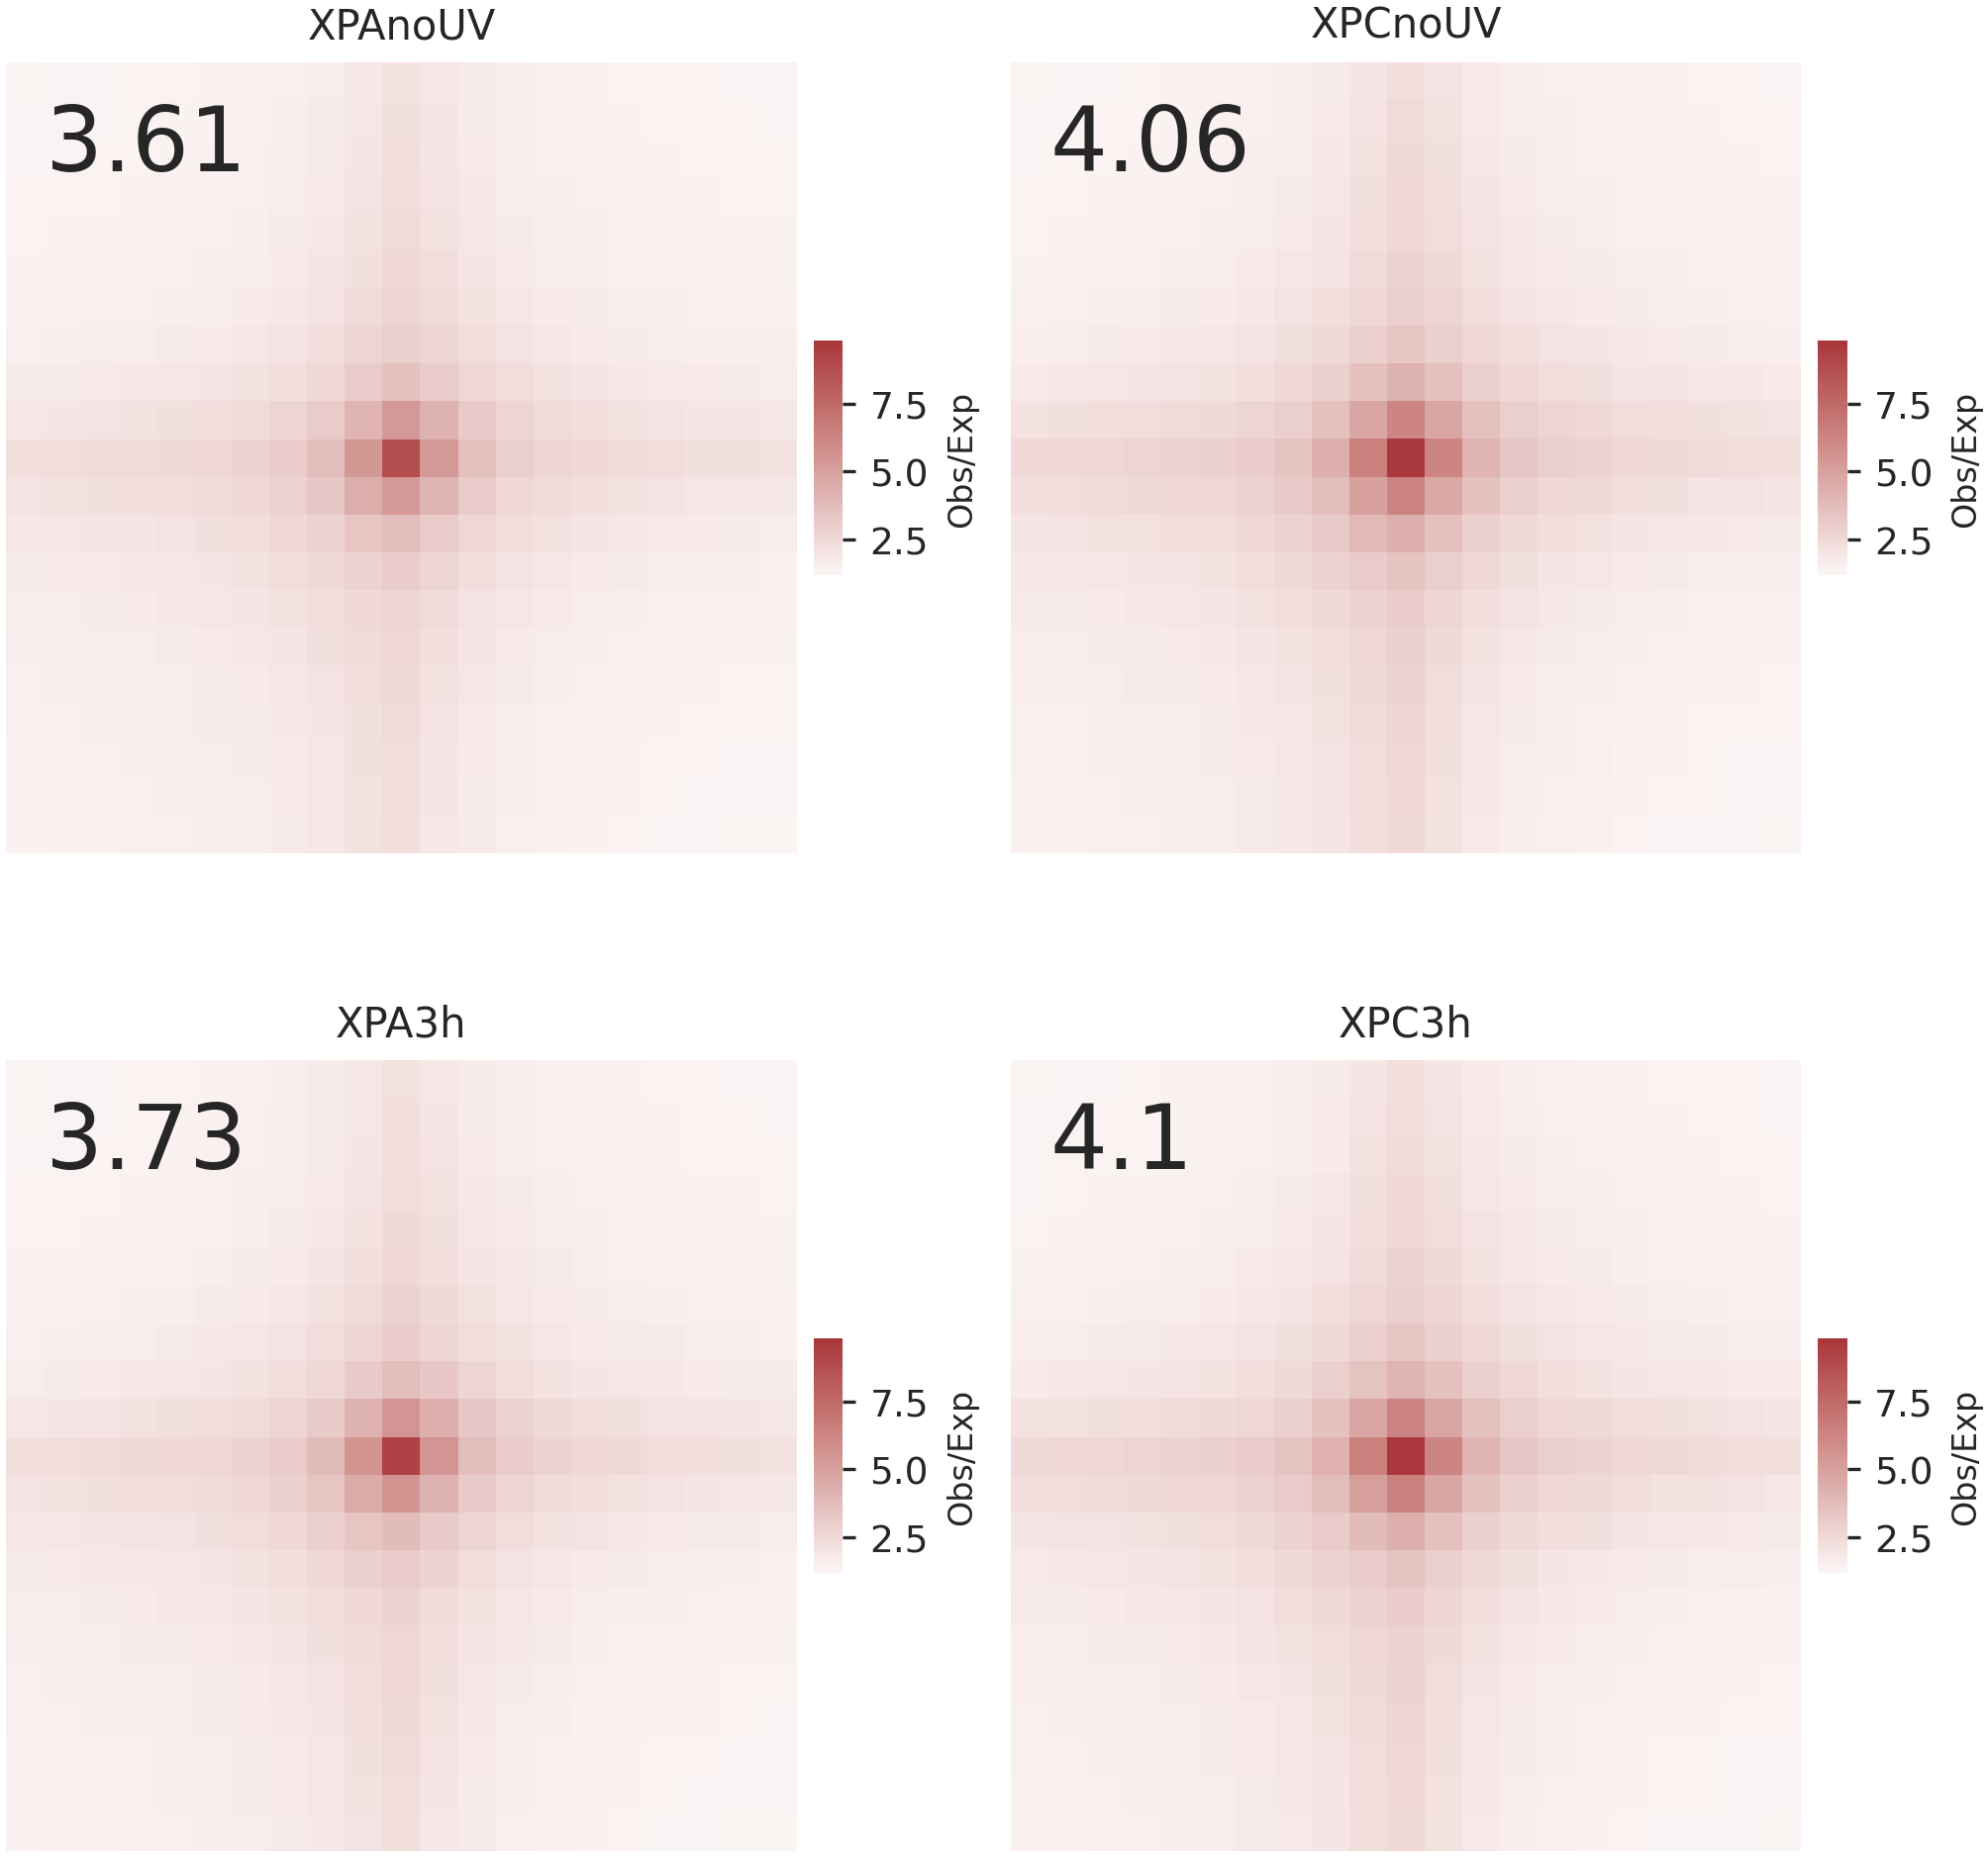

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
plotting.update_rcparams()

xpanouv_pup, xpcnouv_pup = dots_pups_data[('XPAnoUV', 'XPCnoUV')]
xpa3h_pup, xpc3h_pup = dots_pups_data[('XPA3h', 'XPC3h')]


central_size = 1

for pup in [xpanouv_pup, xpcnouv_pup, xpa3h_pup, xpc3h_pup]:
    pup['central_score'] = pup.apply(
                    lambda x: central_score(x['data'], central_size), axis=1
                )
    pup['corner_scores'] = pup.apply(
                    lambda x: get_corner_scores(x['data']), axis=1
                )
    pup['loop_strength'] = pup.apply(
                    lambda x: _quantify_loops(x['data']), axis=1
                )

vmin, vmax = np.nanmin([xpanouv_pup['data'][0], xpcnouv_pup['data'][0], xpa3h_pup['data'][0], xpc3h_pup['data'][0]]), np.nanmax([xpanouv_pup['data'][0], xpcnouv_pup['data'][0], xpa3h_pup['data'][0], xpc3h_pup['data'][0]])

score_type = "loop_strength" # "corner_scores" or "central_score" or "loop_strength"

heatmap_wrapper(xpanouv_pup['data'][0], axs[0,0], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpcnouv_pup['data'][0], axs[0,1], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpa3h_pup['data'][0], axs[1,0], vmin=vmin, vmax=vmax)
heatmap_wrapper(xpc3h_pup['data'][0], axs[1,1], vmin=vmin, vmax=vmax)

# add titles
n_nouv = xpanouv_pup['n'][0]
n_3h = xpa3h_pup['n'][0]
axs[0,0].set_title('XPAnoUV', fontsize=10)
axs[0,1].set_title('XPCnoUV', fontsize=10)
axs[1,0].set_title('XPA3h', fontsize=10)
axs[1,1].set_title('XPC3h', fontsize=10)

add_scores(score_type, xpanouv_pup[score_type][0], axs[0,0], xpanouv_pup['data'][0].shape[0])
add_scores(score_type, xpcnouv_pup[score_type][0], axs[0,1], xpcnouv_pup['data'][0].shape[0])
add_scores(score_type, xpa3h_pup[score_type][0], axs[1,0], xpa3h_pup['data'][0].shape[0])
add_scores(score_type, xpc3h_pup[score_type][0], axs[1,1], xpc3h_pup['data'][0].shape[0])

fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig3/xpa_xpc_loops_apa_scores_{score_type}.png', dpi=300, bbox_inches='tight')
fig.savefig(f'/home/carlos/Clone/ggner-3d/figs/fig3/xpa_xpc_loops_apa_scores_{score_type}.svg', bbox_inches='tight')

### CTCF enrichment at boundaries

In [46]:
from ggner_3d.bbi_helpers import stackup_bw_dict

ctcf_dict = {
    'wtnouv': ['/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw', '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'],
    'xpcnouv': ['/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP1.mLb.clN.rpgc.bw', '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP2.mLb.clN.rpgc.bw'],
    'wt3h': ['/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP1.mLb.clN.rpgc.bw', '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP2.mLb.clN.rpgc.bw'],
    'xpc3h': ['/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP1.mLb.clN.rpgc.bw', '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP2.mLb.clN.rpgc.bw'],
}

atac_dict = {'wtnouv': ['/home/carlos/Clone/ggner-3d/WT_noUV.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw'],
             'xpcnouv': ['/home/carlos/Clone/ggner-3d/XPC_noUV.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw'],
             'wt3h': ['/home/carlos/Clone/ggner-3d/WT_UV3h.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw'],
             'xpc3h': ['/home/carlos/Clone/ggner-3d/XPC_UV3h.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw']}

flank = 250_000
nbins = 150

wtnouv_xpcnouv_boundaries = pd.concat(dfs).loc[lambda df: (df['sample1'] == 'WTnoUV') & (df['sample2'] == 'XPCnoUV')]
wtnouv_xpcnouv_boundaries = chrom_to_bin_indices(wtnouv_xpcnouv_boundaries, bins_table, bin_column='idx1')[['chrom', 'start', 'end']]
wtnouv_xpcnouv_boundaries['flank_start'] = wtnouv_xpcnouv_boundaries['start'] - flank
wtnouv_xpcnouv_boundaries['flank_end'] = wtnouv_xpcnouv_boundaries['end'] + flank
wtnouv_xpcnouv_ctcf_stackup = stackup_bw_dict(ctcf_dict, wtnouv_xpcnouv_boundaries, nbins=nbins)
wtnouv_xpcnouv_atac_stackup = stackup_bw_dict(atac_dict, wtnouv_xpcnouv_boundaries, nbins=nbins)

wt3h_xpc3h_boundaries = pd.concat(dfs).loc[lambda df: (df['sample1'] == 'WT3h') & (df['sample2'] == 'XPC3h')]
wt3h_xpc3h_boundaries = chrom_to_bin_indices(wt3h_xpc3h_boundaries, bins_table, bin_column='idx1')[['chrom', 'start', 'end']]
wt3h_xpc3h_boundaries['flank_start'] = wt3h_xpc3h_boundaries['start'] - flank
wt3h_xpc3h_boundaries['flank_end'] = wt3h_xpc3h_boundaries['end'] + flank
wt3h_xpc3h_ctcf_stackup = stackup_bw_dict(ctcf_dict, wt3h_xpc3h_boundaries, nbins=nbins)
wt3h_xpc3h_atac_stackup = stackup_bw_dict(atac_dict, wt3h_xpc3h_boundaries, nbins=nbins)

wtnouv_wt3h_boundaries = pd.concat(dfs).loc[lambda df: (df['sample1'] == 'WTnoUV') & (df['sample2'] == 'WT3h')]
wtnouv_wt3h_boundaries = chrom_to_bin_indices(wtnouv_wt3h_boundaries, bins_table, bin_column='idx1')[['chrom', 'start', 'end']]
wtnouv_wt3h_boundaries['flank_start'] = wtnouv_wt3h_boundaries['start'] - flank
wtnouv_wt3h_boundaries['flank_end'] = wtnouv_wt3h_boundaries['end'] + flank
wtnouv_wt3h_ctcf_stackup = stackup_bw_dict(ctcf_dict, wtnouv_wt3h_boundaries, nbins=nbins)
wtnouv_wt3h_atac_stackup = stackup_bw_dict(atac_dict, wtnouv_wt3h_boundaries, nbins=nbins)

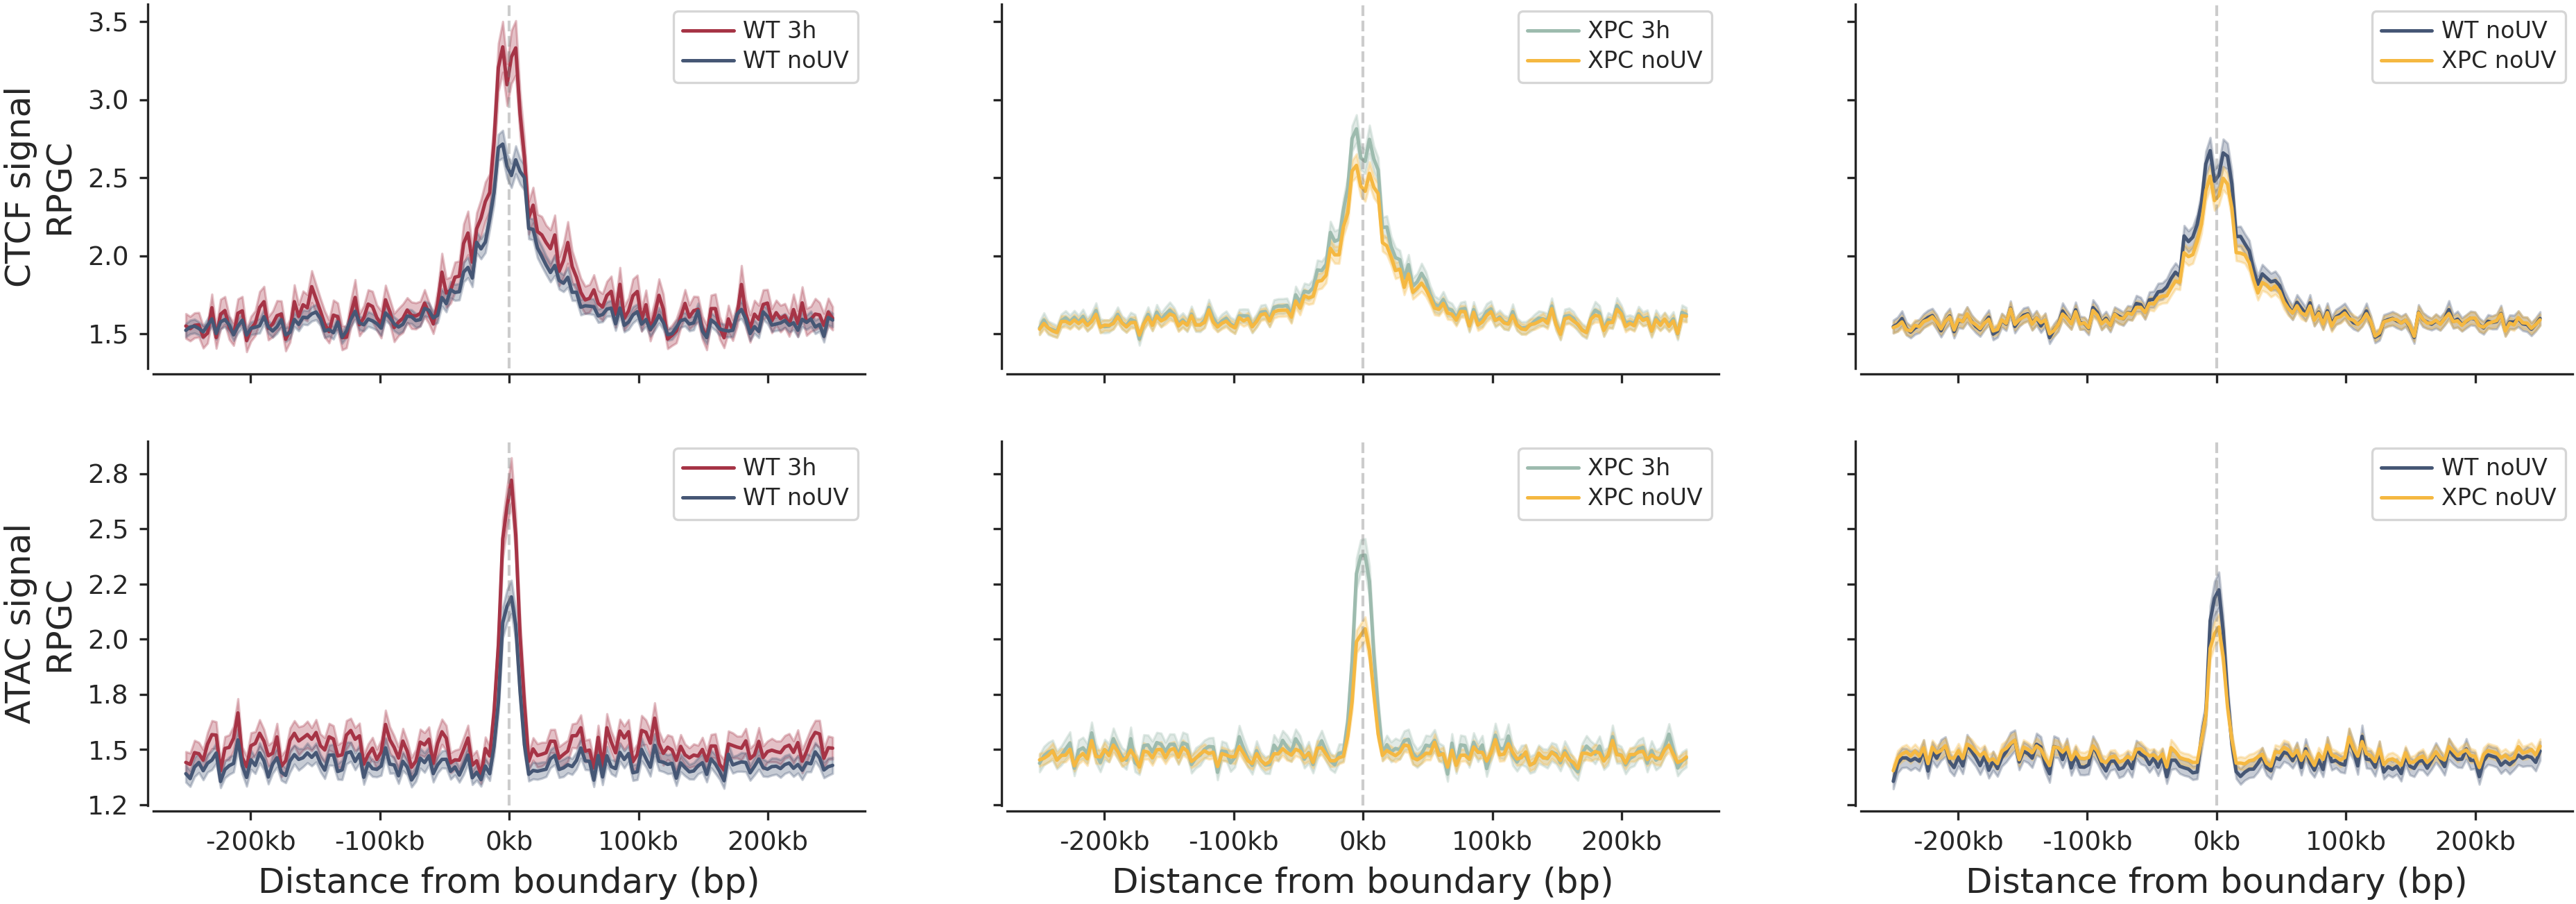

In [47]:
colors = plotting.COLORS

sf = 2.5/4
fig, ax = plt.subplots(2, 3, figsize=(24*sf, 8*sf), sharey='row', sharex=True)

plotting.update_rcparams()

def lineplot_wrapper(x, y2d, ax, color, label):
    """
    y2d: array of shape (n_regions, nbins) OR (nbins,)
    plots mean ± SEM across regions
    returns max abs bound used by mean±sem (for y-limit setting)
    """
    y2d = np.asarray(y2d)

    if y2d.ndim == 1:
        mean_y = y2d
        sem_y = np.zeros_like(mean_y)
    else:
        mean_y = np.nanmean(y2d, axis=0)
        n = np.sum(~np.isnan(y2d), axis=0)
        sem_y = np.nanstd(y2d, axis=0) / np.sqrt(np.maximum(n, 1))

    ax.plot(x, mean_y, color=color, label=label)
    sns.despine(ax=ax, top=True, right=True, offset=2, trim=False)

    ax.fill_between(
        x,
        mean_y - sem_y,
        mean_y + sem_y,
        color=color,
        alpha=0.3
    )

    return np.nanmax(np.abs(np.r_[mean_y - sem_y, mean_y + sem_y]))

color_mapping = {
    'wtnouv': colors[0],
    'wt3h': colors[1],
    'xpcnouv': colors[2],
    'xpc3h': colors[3]
}

comp_plots = [
    ('wt3h', 'wtnouv'),
    ('xpc3h', 'xpcnouv'),
    ('wtnouv', 'xpcnouv'),
]

sample_mapping = {
    'wtnouv': 'WT noUV',
    'wt3h': 'WT 3h',
    'xpcnouv': 'XPC noUV',
    'xpc3h': 'XPC 3h'
}

def mean_signal(arr):
    # return np.nanmean(arr, axis=0)
    return arr

x = np.linspace(-flank, flank, nbins)
ticks = np.array([-200_000, -100_000, 0, 100_000, 200_000])

ctcf_all_stackup = [
    wtnouv_wt3h_ctcf_stackup,
    wtnouv_xpcnouv_ctcf_stackup,
    wt3h_xpc3h_ctcf_stackup
]

# --- CTCF row ---
for i, (k1, k2) in enumerate(comp_plots):
    y1 = mean_signal(ctcf_all_stackup[i][k1])
    y2 = mean_signal(ctcf_all_stackup[i][k2])

    ax_now = ax[0, i]

    lineplot_wrapper(x, y1, ax_now, color=color_mapping[k1], label=sample_mapping[k1])
    lineplot_wrapper(x, y2, ax_now, color=color_mapping[k2], label=sample_mapping[k2])

    ax_now.legend()
    if i == 0:
        ax_now.set_ylabel('CTCF signal\nRPGC')

    ax_now.set_xticks(ticks)
    ax_now.set_xticklabels([f"{t//1000}kb" for t in ticks])
    ax_now.axvline(0, color='grey', linestyle='--', linewidth=1, alpha=0.4)

atac_all_stackup = [
    wtnouv_wt3h_atac_stackup,
    wtnouv_xpcnouv_atac_stackup,
    wt3h_xpc3h_atac_stackup
]

# --- ATAC row ---
for i, (k1, k2) in enumerate(comp_plots):
    y1 = mean_signal(atac_all_stackup[i][k1])
    y2 = mean_signal(atac_all_stackup[i][k2])

    ax_now = ax[1, i]

    lineplot_wrapper(x, y1, ax_now, color=color_mapping[k1], label=sample_mapping[k1])
    lineplot_wrapper(x, y2, ax_now, color=color_mapping[k2], label=sample_mapping[k2])

    ax_now.legend()
    ax_now.set_xlabel('Distance from boundary (bp)')
    if i == 0:
        ax_now.set_ylabel('ATAC signal\nRPGC')

    ax_now.set_xticks(ticks)
    labels = [f"{t//1000}kb" for t in ticks]
    ax_now.set_xticklabels(labels)
    ax_now.axvline(0, color='grey', linestyle='--', linewidth=1, alpha=0.4)

from matplotlib.ticker import FormatStrFormatter

for a in ax.flatten():
    a.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/wt_xpc_boundaries_ctcf_atac.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/wt_xpc_boundaries_ctcf_atac.svg', bbox_inches='tight')

In [33]:
def prepare_loop_coords(df, on='sample_a', flank_ratio=0.25):
    df = df.copy()
    df['chrom1'] = df[f'chrom1_{on}']
    df['start1'] = df[f'start1_{on}']
    df['end1'] = df[f'end1_{on}']
    df['chrom2'] = df[f'chrom2_{on}']
    df['start2'] = df[f'start2_{on}']
    df['end2'] = df[f'end2_{on}']
    
    df['chrom'] = df['chrom1']
    df['length'] = df['end2'] - df['start1']
    df['flank_start'] = df['start1'] - (df['length'] * flank_ratio).astype(int)
    df['flank_end'] = df['end2'] + (df['length'] * flank_ratio).astype(int)

    return df[['chrom', 'flank_start', 'flank_end']]

wtnouv_xpcnouv_loops = prepare_loop_coords(compare_loops_with_strength(
    df_a=dots_dfs_[all_samples.index('WTnoUV')],
    df_b=dots_dfs_[all_samples.index('XPCnoUV')],
    clustering_radius=clustering_radius,
    compute_strength=False
)['common_loops'])

wtnouv_wt3h_loops = prepare_loop_coords(compare_loops_with_strength(
    df_a=dots_dfs_[all_samples.index('WTnoUV')],
    df_b=dots_dfs_[all_samples.index('WT3h')],
    clustering_radius=clustering_radius,
    compute_strength=False
)['common_loops'])

xpcnouv_xpc3h_loops = prepare_loop_coords(compare_loops_with_strength(
    df_a=dots_dfs_[all_samples.index('XPCnoUV')],
    df_b=dots_dfs_[all_samples.index('XPC3h')],
    clustering_radius=clustering_radius,
    compute_strength=False
)['common_loops'])

wtnouv_xpcnouv_loops_stackup_ctcf = stackup_bw_dict({k:v for k,v in ctcf_dict.items() if k in ['wtnouv', 'xpcnouv']}, wtnouv_xpcnouv_loops, nbins=nbins)
wtnouv_wt3h_loops_stackup_ctcf = stackup_bw_dict({k:v for k,v in ctcf_dict.items() if k in ['wtnouv', 'wt3h']}, wtnouv_wt3h_loops, nbins=nbins)
xpcnouv_xpc3h_loops_stackup_ctcf = stackup_bw_dict({k:v for k,v in ctcf_dict.items() if k in ['xpcnouv', 'xpc3h']}, xpcnouv_xpc3h_loops, nbins=nbins)

wtnouv_xpcnouv_loops_stackup_atac = stackup_bw_dict({k:v for k,v in atac_dict.items() if k in ['wtnouv', 'xpcnouv']}, wtnouv_xpcnouv_loops, nbins=nbins)
wtnouv_wt3h_loops_stackup_atac = stackup_bw_dict({k:v for k,v in atac_dict.items() if k in ['wtnouv', 'wt3h']}, wtnouv_wt3h_loops, nbins=nbins)
xpcnouv_xpc3h_loops_stackup_atac = stackup_bw_dict({k:v for k,v in atac_dict.items() if k in ['xpcnouv', 'xpc3h']}, xpcnouv_xpc3h_loops, nbins=nbins)

/home/carlos/Clone/ggner-3d/src/ggner_3d/bbi_helpers.py:19: RuntimeWarning: Mean of empty slice
  bw_dict_rep_avg = {k: np.nanmean(np.array(v), axis=0) for k, v in bw_dict_rep_avg.items()}


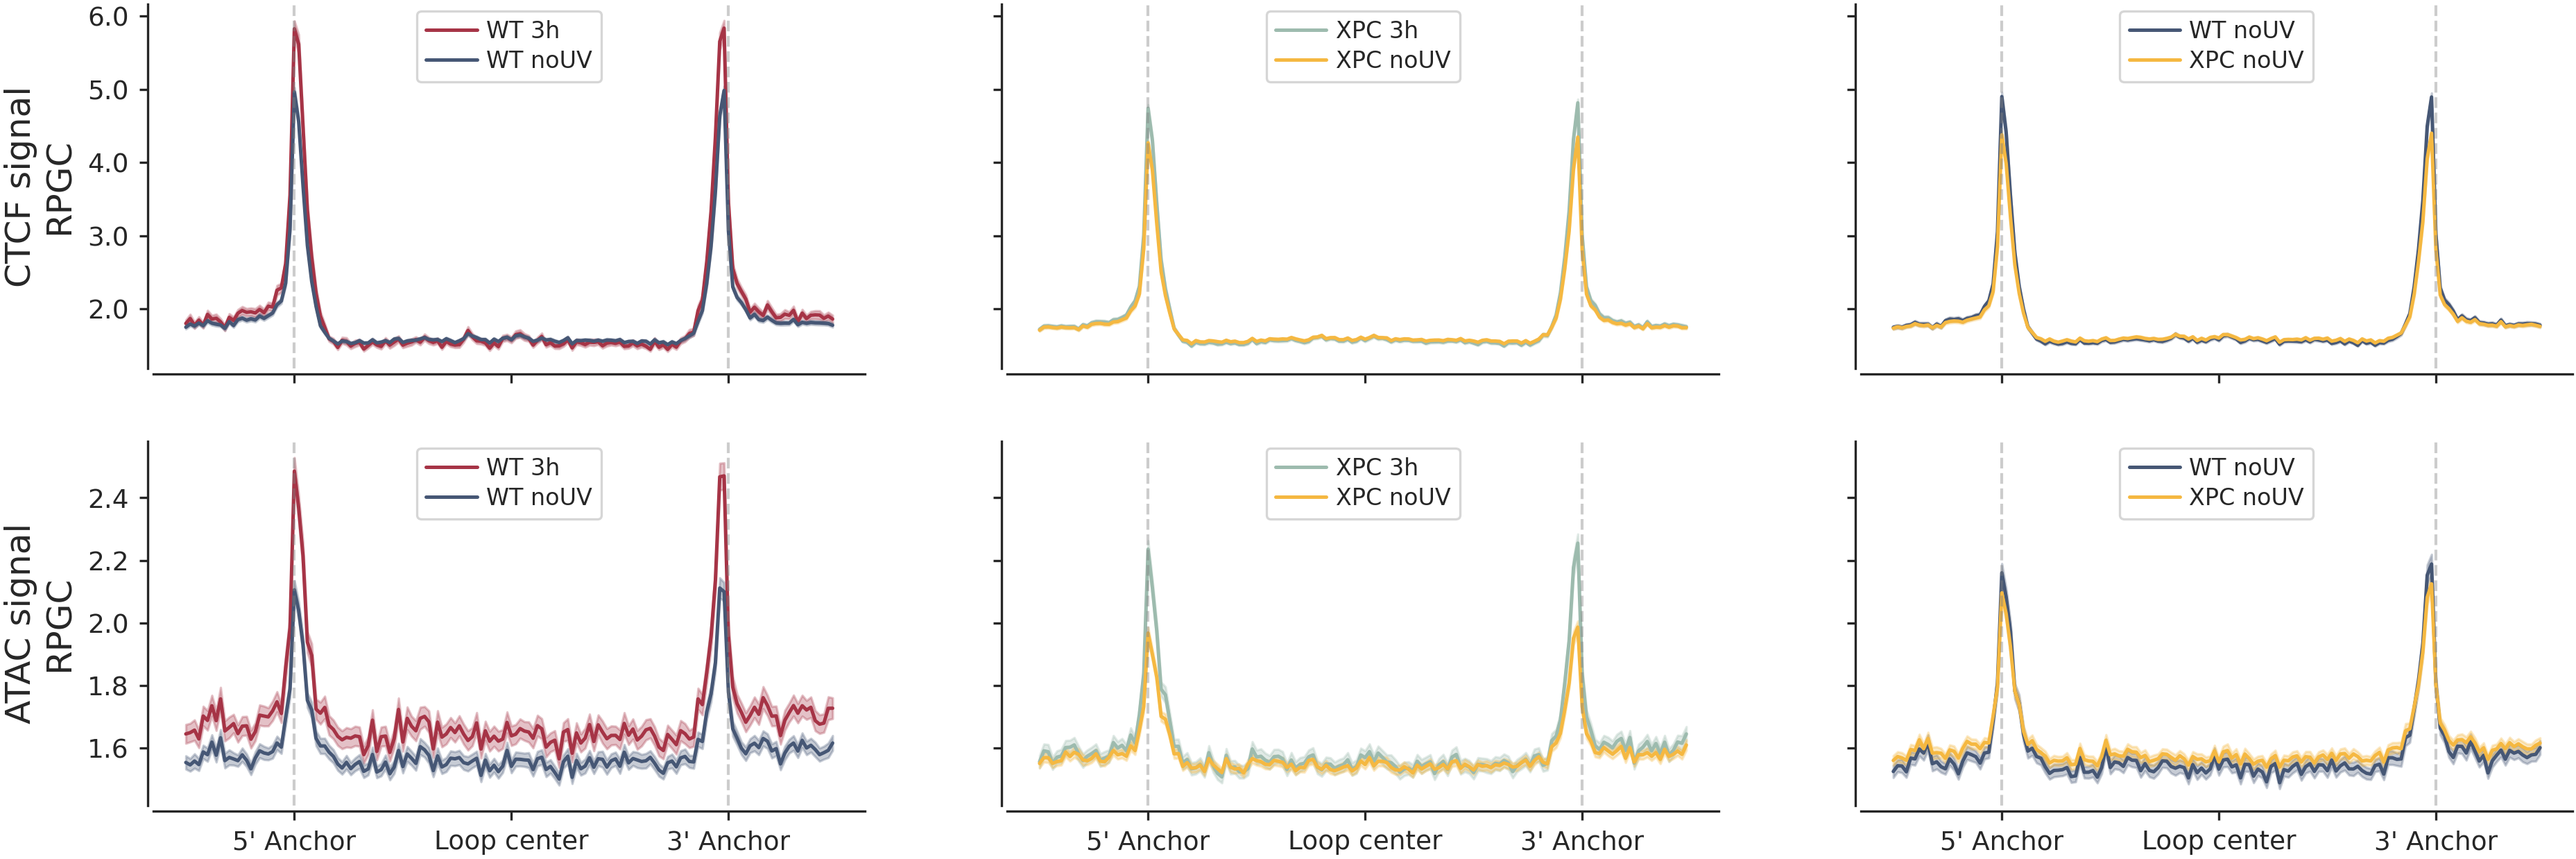

In [34]:
colors = plotting.COLORS

sf = 2.5/4
fig, ax = plt.subplots(2, 3, figsize=(24*sf, 8*sf), sharey='row', sharex=True)

plotting.update_rcparams()

def lineplot_wrapper(x, y2d, ax, color, label):
    """
    y2d: array of shape (n_regions, nbins) OR (nbins,)
    plots mean ± SEM across regions
    returns max abs bound used by mean±sem (for y-limit setting)
    """
    y2d = np.asarray(y2d)

    if y2d.ndim == 1:
        mean_y = y2d
        sem_y = np.zeros_like(mean_y)
    else:
        mean_y = np.nanmean(y2d, axis=0)
        n = np.sum(~np.isnan(y2d), axis=0)
        sem_y = np.nanstd(y2d, axis=0) / np.sqrt(np.maximum(n, 1))

    ax.plot(x, mean_y, color=color, label=label)
    sns.despine(ax=ax, top=True, right=True, offset=2, trim=False)

    ax.fill_between(
        x,
        mean_y - sem_y,
        mean_y + sem_y,
        color=color,
        alpha=0.3
    )

    return np.nanmax(np.abs(np.r_[mean_y - sem_y, mean_y + sem_y]))

color_mapping = {
    'wtnouv': colors[0],
    'wt3h': colors[1],
    'xpcnouv': colors[2],
    'xpc3h': colors[3]
}

comp_plots = [
    ('wt3h', 'wtnouv'),
    ('xpc3h', 'xpcnouv'),
    ('wtnouv', 'xpcnouv'),
]

sample_mapping = {
    'wtnouv': 'WT noUV',
    'wt3h': 'WT 3h',
    'xpcnouv': 'XPC noUV',
    'xpc3h': 'XPC 3h'
}

x = np.linspace(-flank, flank, nbins)
ticks = np.array([-200_000, -100_000, 0, 100_000, 200_000])

ctcf_all_stackup = [
    wtnouv_wt3h_loops_stackup_ctcf,
    xpcnouv_xpc3h_loops_stackup_ctcf,
    wtnouv_xpcnouv_loops_stackup_ctcf,
]

# --- CTCF row ---
for i, (k1, k2) in enumerate(comp_plots):
    y1 = mean_signal(ctcf_all_stackup[i][k1])   # shape (n_regions, nbins) -> (nbins,)
    y2 = mean_signal(ctcf_all_stackup[i][k2])

    ax_now = ax[0, i]

    lineplot_wrapper(x, y1, ax_now, color=color_mapping[k1], label=sample_mapping[k1])
    lineplot_wrapper(x, y2, ax_now, color=color_mapping[k2], label=sample_mapping[k2])

    ax_now.legend()
    if i == 0:
        ax_now.set_ylabel('CTCF signal\nRPGC')


atac_all_stackup = [
    wtnouv_wt3h_loops_stackup_atac,
    xpcnouv_xpc3h_loops_stackup_atac,
    wtnouv_xpcnouv_loops_stackup_atac,
]

# --- ATAC row ---
for i, (k1, k2) in enumerate(comp_plots):
    y1 = mean_signal(atac_all_stackup[i][k1])
    y2 = mean_signal(atac_all_stackup[i][k2])

    ax_now = ax[1, i]

    lineplot_wrapper(x, y1, ax_now, color=color_mapping[k1], label=sample_mapping[k1])
    lineplot_wrapper(x, y2, ax_now, color=color_mapping[k2], label=sample_mapping[k2])

    ax_now.legend()
    if i == 0:
        ax_now.set_ylabel('ATAC signal\nRPGC')


from matplotlib.ticker import FormatStrFormatter

total_perc = 150
fiveprime_anchor_bin = 25 * nbins // total_perc
threeprime_anchor_bin = 125 * nbins // total_perc
center_bin = 75 * nbins // total_perc

x_5p = x[fiveprime_anchor_bin]
x_center = x[center_bin]
x_3p = x[threeprime_anchor_bin]

for a in ax.flatten():
    a.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    a.set_xticks([x_5p, x_center, x_3p])
    a.set_xticklabels(["5' Anchor", "Loop center", "3' Anchor"])

    a.axvline(x_5p, color='grey', linestyle='--', linewidth=1, alpha=0.4)
    a.axvline(x_3p, color='grey', linestyle='--', linewidth=1, alpha=0.4)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/wt_xpc_loops_ctcf_atac.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig3/wt_xpc_loops_ctcf_atac.svg', bbox_inches='tight')

### ctcf peaks in boundaries

In [35]:
def filter_peaks(df, score=540):
    df_now = df.loc[df[4] >= score][[0,1,2]].rename(columns={0: 'chrom', 1: 'start', 2: 'end'})
    print(f"Filtered {len(df_now)} peaks with score >= {score}")
    return df_now

ctcf_peaks_wtnouv = filter_peaks(pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/WT_NoUV_idr_conservative_merged.narrowPeak', sep='\t', header=None))
ctcf_peaks_xpcnouv = filter_peaks(pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/XPCKO_NoUV_idr_conservative_merged.narrowPeak', sep='\t', header=None))
ctcf_peaks_wt3h = filter_peaks(pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/WT_3h_idr_conservative_merged.narrowPeak', sep='\t', header=None))
ctcf_peaks_xpc3h = filter_peaks(pd.read_csv('/home/carlos/oldies/ner_collab/ctcf/idr/XPCKO_3h_idr_conservative_merged.narrowPeak', sep='\t', header=None))

flank = 20_000

wtnouv_xpcnouv_common_boundaries = pd.concat(dfs).loc[lambda df: (df['sample1'] == 'WTnoUV') & (df['sample2'] == 'XPCnoUV')]
wtnouv_xpcnouv_common_boundaries = chrom_to_bin_indices(wtnouv_xpcnouv_common_boundaries, bins_table, bin_column='idx1')[['chrom', 'start', 'end']]
wtnouv_xpcnouv_common_boundaries['start'] -= flank
wtnouv_xpcnouv_common_boundaries['end'] += flank

wt3h_xpc3h_common_boundaries = pd.concat(dfs).loc[lambda df: (df['sample1'] == 'WT3h') & (df['sample2'] == 'XPC3h')]
wt3h_xpc3h_common_boundaries = chrom_to_bin_indices(wt3h_xpc3h_common_boundaries, bins_table, bin_column='idx1')[['chrom', 'start', 'end']]
wt3h_xpc3h_common_boundaries['start'] -= flank
wt3h_xpc3h_common_boundaries['end'] += flank

peak_cov_wtnouv = bf.coverage(wtnouv_xpcnouv_common_boundaries, ctcf_peaks_wtnouv)
peak_cov_xpcnouv = bf.coverage(wtnouv_xpcnouv_common_boundaries, ctcf_peaks_xpcnouv)
peak_cov_wt3h = bf.coverage(wt3h_xpc3h_common_boundaries, ctcf_peaks_wt3h)
peak_cov_xpc3h = bf.coverage(wt3h_xpc3h_common_boundaries, ctcf_peaks_xpc3h)

Filtered 35440 peaks with score >= 540
Filtered 24335 peaks with score >= 540
Filtered 16095 peaks with score >= 540
Filtered 42182 peaks with score >= 540


In [36]:
# both covereage 0 on peak_cov_wtnouv and peak_cov_xpcnouv
nouv_cov = pd.merge(peak_cov_wtnouv, peak_cov_xpcnouv, on=['chrom', 'start', 'end'], suffixes=('_wtnouv', '_xpcnouv'))
nouv_cov = nouv_cov.loc[~((nouv_cov['coverage_wtnouv'] == 0) | (nouv_cov['coverage_xpcnouv'] == 0))]
_3h_cov = pd.merge(peak_cov_wt3h, peak_cov_xpc3h, on=['chrom', 'start', 'end'], suffixes=('_wt3h', '_xpc3h'))
_3h_cov = _3h_cov.loc[~((_3h_cov['coverage_wt3h'] == 0) | (_3h_cov['coverage_xpc3h'] == 0))]

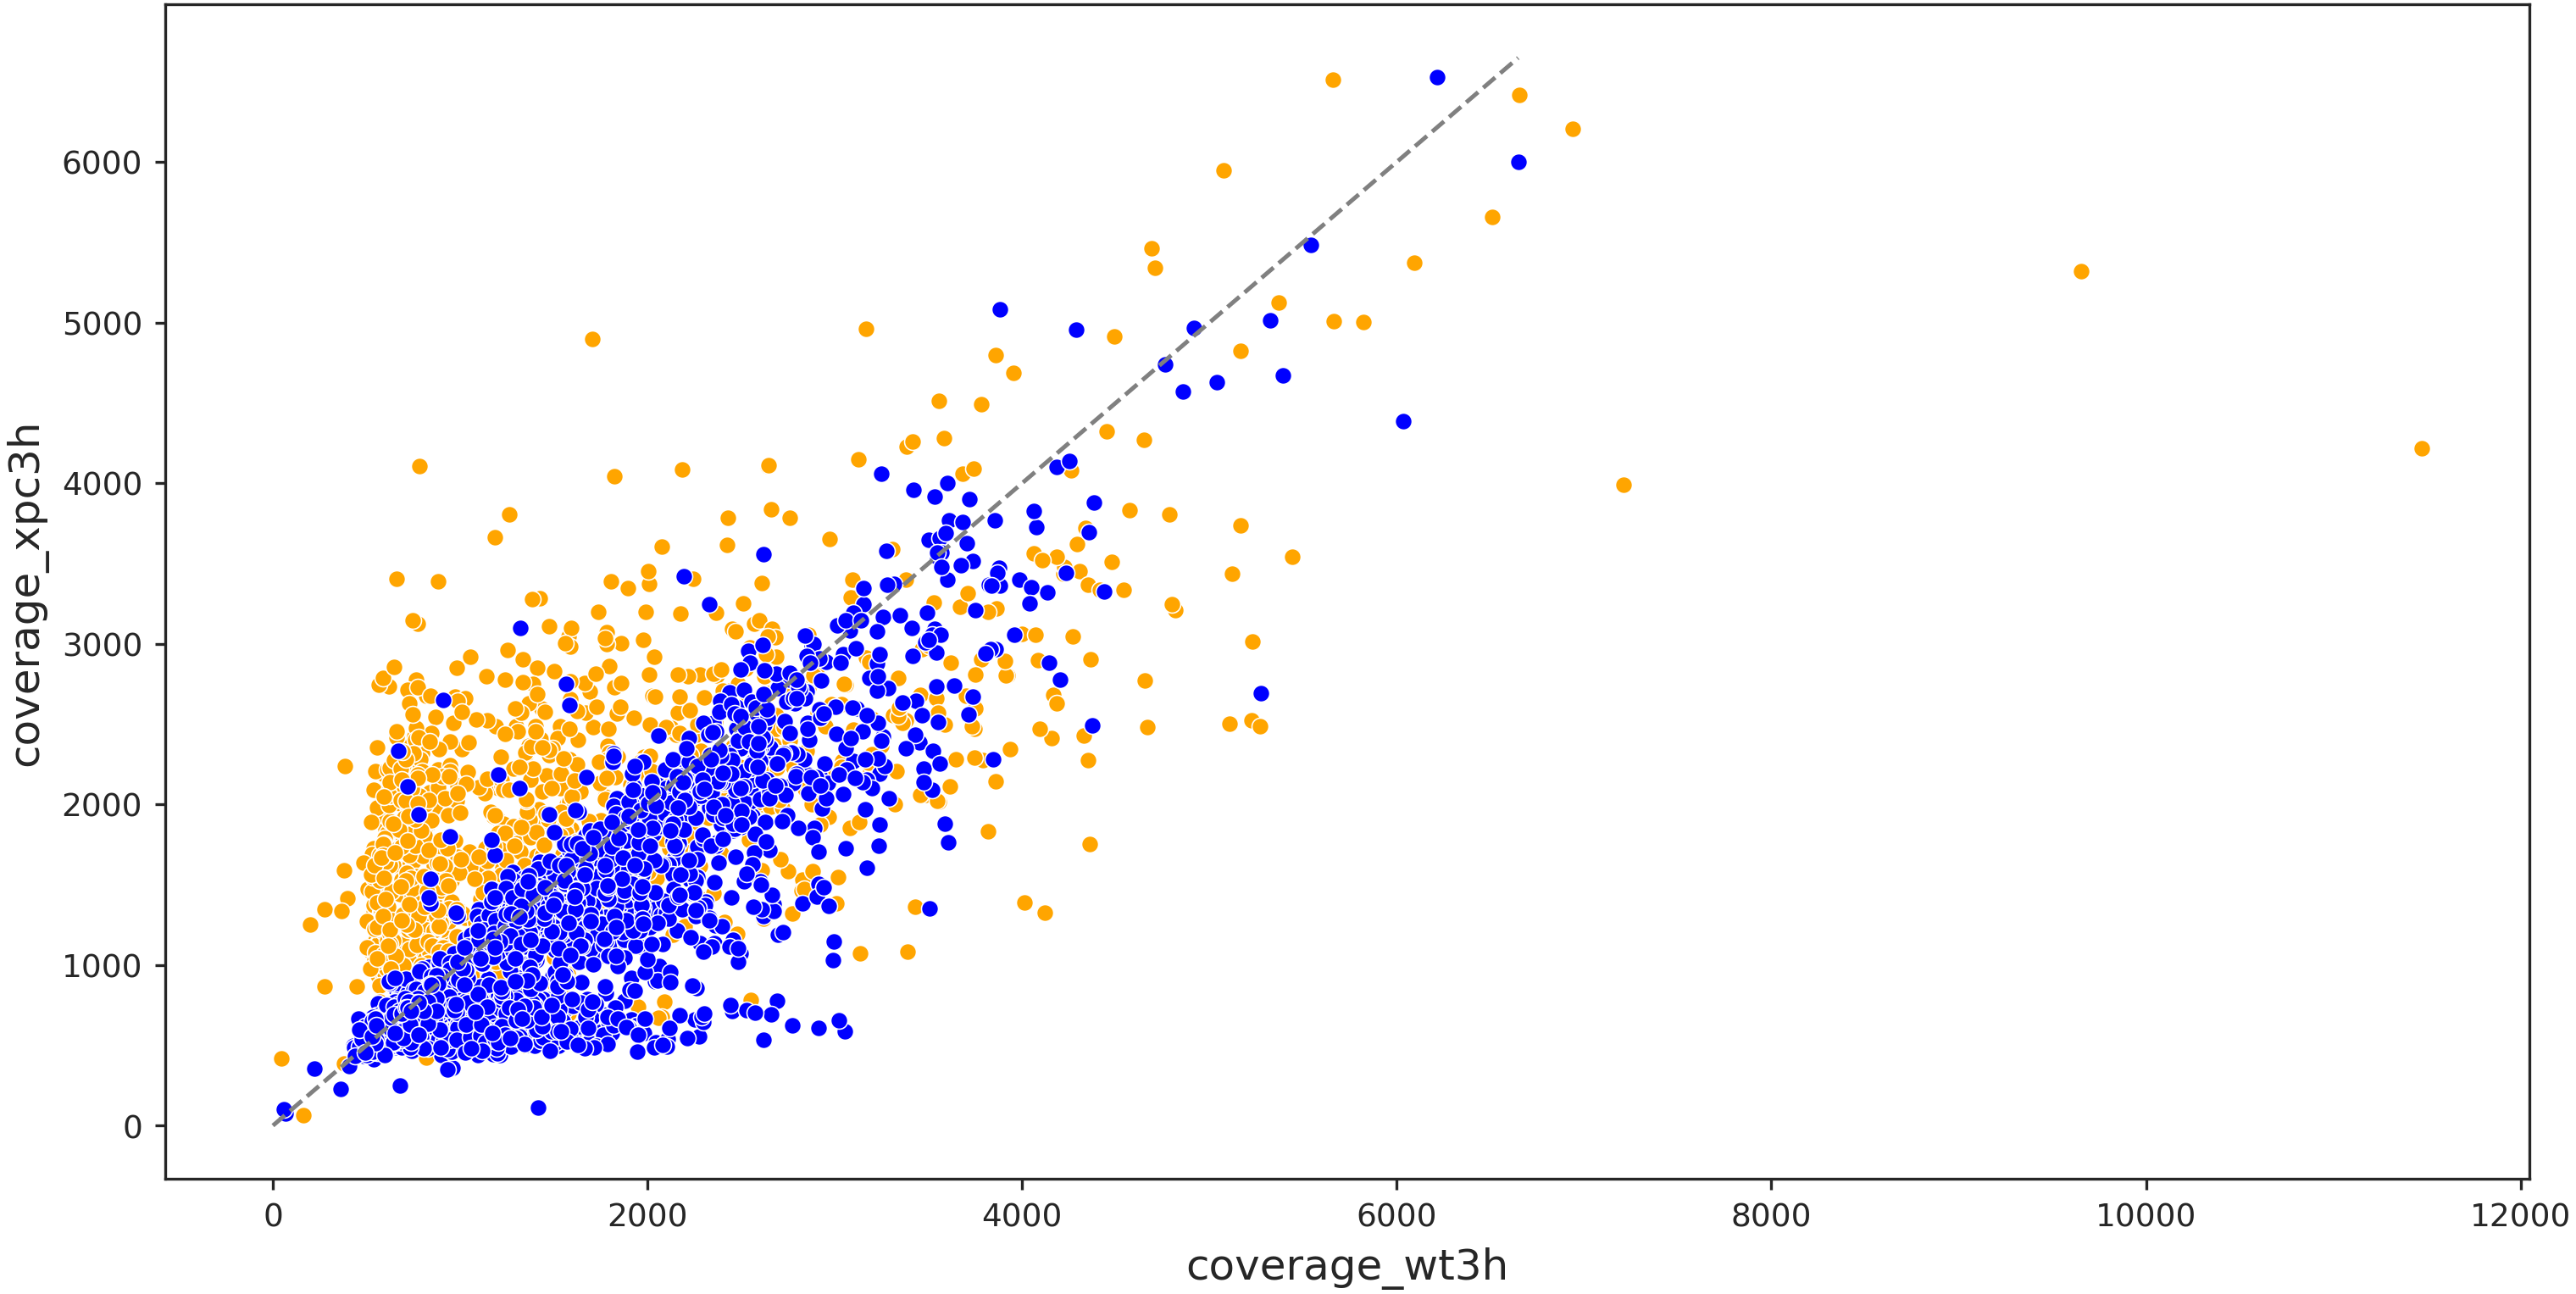

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.scatterplot(x=_3h_cov.coverage_wt3h, y=_3h_cov.coverage_xpc3h, ax=ax, color='orange')

sns.scatterplot(x=nouv_cov.coverage_wtnouv, y=nouv_cov.coverage_xpcnouv, ax=ax, color='blue')

# add diagonal line
ax.plot([0, max(nouv_cov.coverage_wtnouv.max(), nouv_cov.coverage_xpcnouv.max())], [0, max(nouv_cov.coverage_wtnouv.max(), nouv_cov.coverage_xpcnouv.max())], color='grey', linestyle='--')

### wtnouv vs xpcnouv - tads - Quartiles Groups

In [38]:
wtnouv_xpcnouv_df = dfs[0]

def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

wtnouv_xpcnouv_df = chrom_to_bin_indices(wtnouv_xpcnouv_df, clr_['WTnoUV'].bins()[:], bin_column='idx1')
wtnouv_xpcnouv_df_boundaries = wtnouv_xpcnouv_df[['chrom', 'start', 'end']].drop_duplicates()
wtnouv_xpcnouv_df_tads = make_tads(wtnouv_xpcnouv_df_boundaries, maxlen=MAXLEN, minlen=MINLEN)

view_df = prepare_view_df(arm=False)

from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score

wtnouv_domain_strength = assign_domain_score(
    tads_df = wtnouv_xpcnouv_df_tads,
    clr = clr_['WTnoUV'],
    expected = get_expected_cis_df('WTnoUV', resolution_kb=bin_bp//1000, label='chrom'),
    view_df = view_df,
    clr_weight_name='sweight',
    ignore_diags=2
)

xpcnouv_domain_strength = assign_domain_score(
    tads_df = wtnouv_xpcnouv_df_tads,
    clr = clr_['XPCnoUV'],
    expected = get_expected_cis_df('XPCnoUV', resolution_kb=bin_bp//1000, label='chrom'),
    view_df = view_df,
    clr_weight_name='sweight',
    ignore_diags=2
)

wtnouv_domain_df = pd.merge(wtnouv_xpcnouv_df_tads, wtnouv_domain_strength, on=['chrom', 'start', 'end'])
xpcnouv_domain_df = pd.merge(wtnouv_xpcnouv_df_tads, xpcnouv_domain_strength, on=['chrom', 'start', 'end'])

wtnouv_xpcnouv_common_tads_ds = pd.merge(wtnouv_domain_df, xpcnouv_domain_df, on=['chrom', 'start', 'end'], suffixes=('_control', '_degron'))
wtnouv_xpcnouv_common_tads_ds['delta_strength'] = wtnouv_xpcnouv_common_tads_ds['domain_score_degron'] - wtnouv_xpcnouv_common_tads_ds['domain_score_control']
wtnouv_xpcnouv_common_tads_ds['ds_Q'] = pd.qcut(wtnouv_xpcnouv_common_tads_ds['delta_strength'], q=4, labels=False) + 1
wtnouv_xpcnouv_common_tads_ds['control_Q'] = pd.qcut(wtnouv_xpcnouv_common_tads_ds['domain_score_control'], q=4, labels=False) + 1

eps = 1e-6
wtnouv_xpcnouv_common_tads_ds['delta_strength_l2fc'] = np.log2((wtnouv_xpcnouv_common_tads_ds['domain_score_degron'] + eps) / (wtnouv_xpcnouv_common_tads_ds['domain_score_control'] + eps))
wtnouv_xpcnouv_common_tads_ds['ds_Q_l2fc'] = pd.qcut(wtnouv_xpcnouv_common_tads_ds['delta_strength_l2fc'], q=4, labels=False) + 1

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4', 'chr4'): 159
INFO:coolpuppy:('chr6', 'chr6'): 148
INFO:coolpuppy:('chr5', 'chr5'): 152
INFO:coolpuppy:('chr3', 'chr3'): 169
INFO:coolpuppy:('chr1', 'chr1'): 211
INFO:coolpuppy:('chr2', 'chr2'): 192
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr7', 'chr7'): 130
INFO:coolpuppy:('chr10', 'chr10'): 111
INFO:coolpuppy:('chr8', 'chr8'): 125
INFO:coolpuppy:('chr13', 'chr13'): 75
INFO:coolpuppy:('chr11', 'chr11'): 142
INFO:coolpuppy:('chr12', 'chr12'): 123
INFO:coolpuppy:('chr14', 'chr14'): 75
INFO:coolpuppy:('chr16', 'chr16'): 64
INFO:coolpuppy:('chr15', 'chr15'): 79
INFO:coolpuppy:('chr17', 'chr17'): 66
INFO:coolpuppy:('chr19', 'chr19'): 56
INFO:coolpuppy:('chr18', 'chr18'): 61
INFO:coolpuppy:('chr21', 'chr21'): 19
INFO:coolpuppy:('chr22', 'chr22'): 28
INFO:coolpuppy:('chr20', 'chr20'): 65
INFO:coolpuppy:('chrX', 'chrX'): 91
INFO:coolpuppy:Total number of piled up windows: 211
INFO:coolpuppy:Res

In [39]:
ctcf_wt_dict = {
'wt_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'
],
'xpcko_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP2.mLb.clN.rpgc.bw'
]
}

pol2_wt_dict = {
    'wt_nouv_pol2': ["/home/carlos/Clone/ggner-3d/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"]}


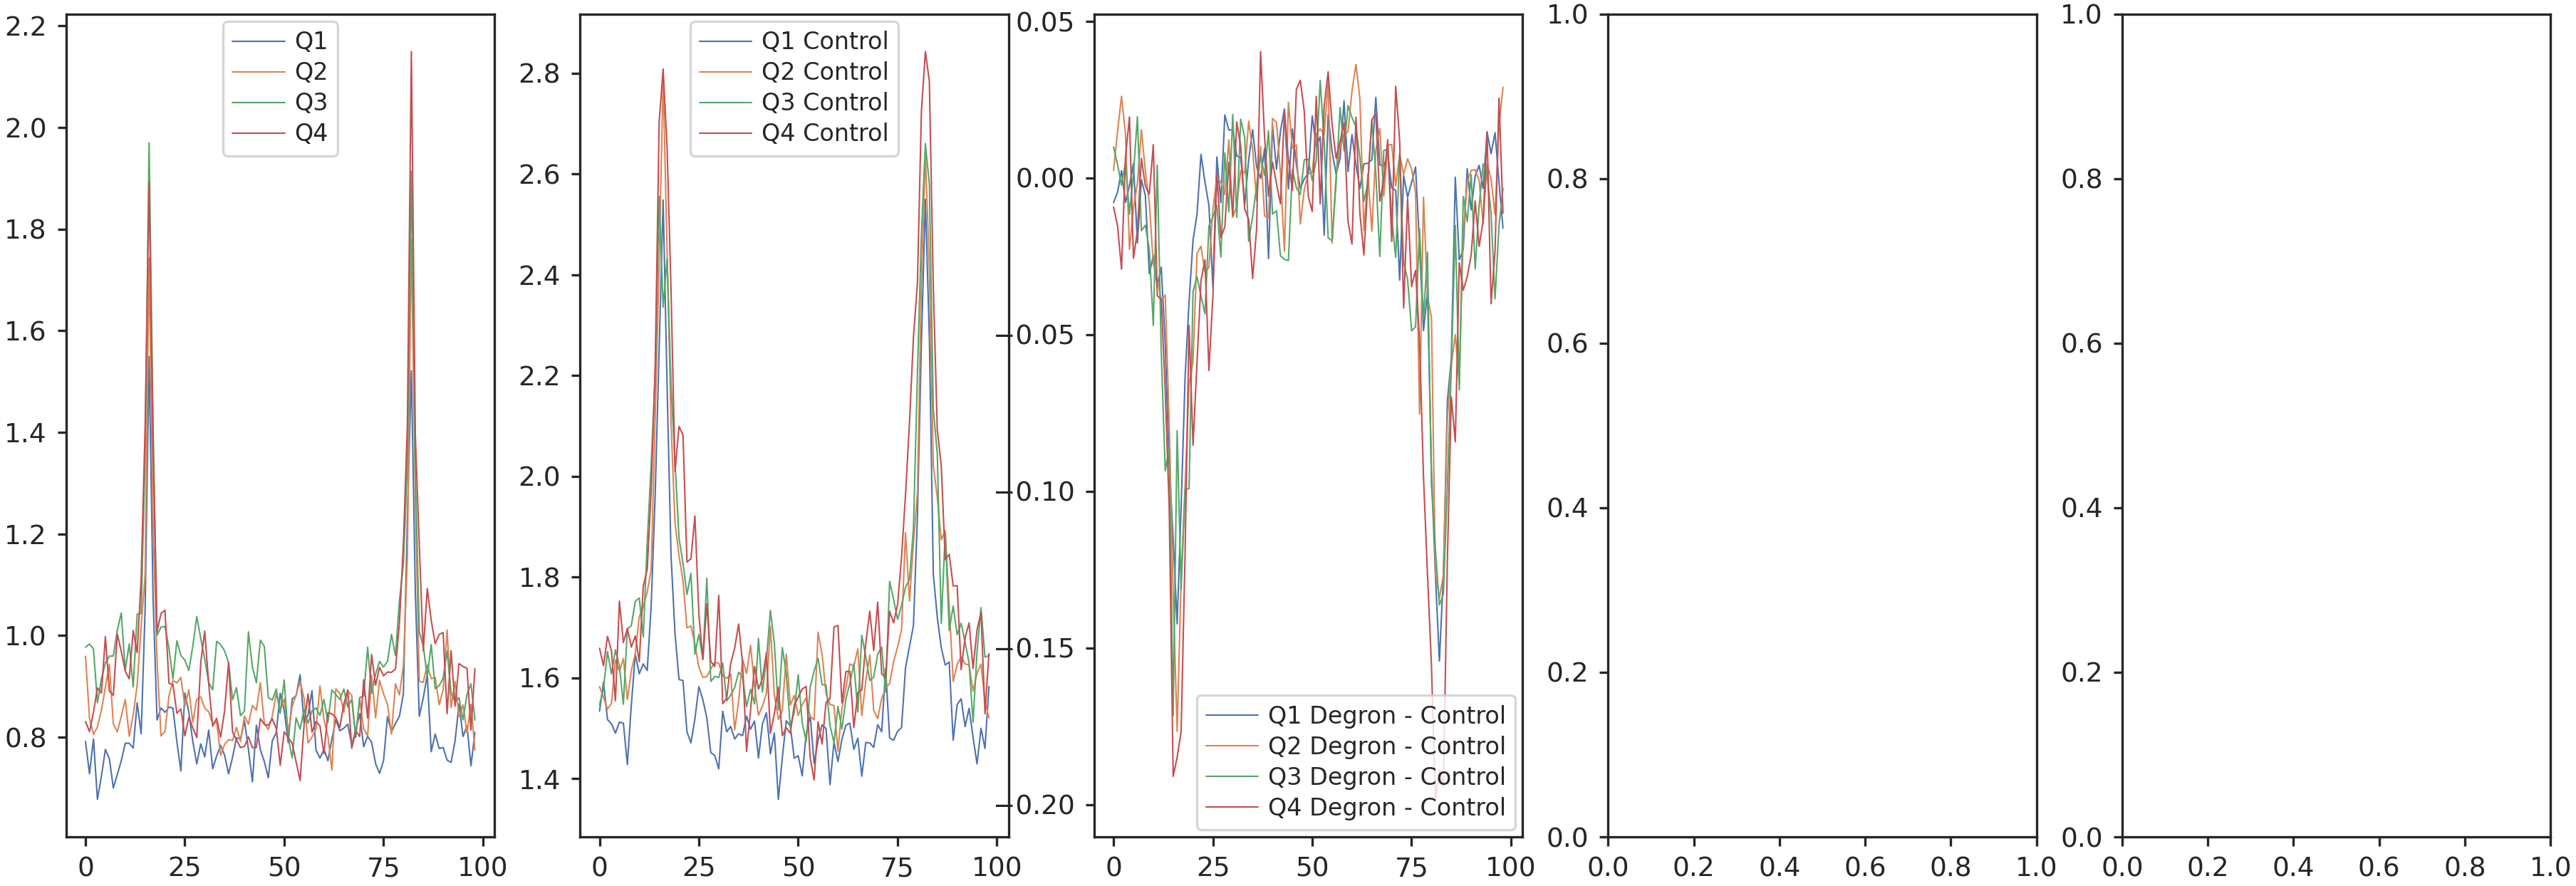

In [40]:
flank_ratio = 0.25
nbins = 99

fig, axs = plt.subplots(1, 5, figsize=(15, 5))

from ggner_3d.bbi_helpers import stackup_bw_dict

for Q in range(1, 5):
    current_tads = wtnouv_xpcnouv_common_tads_ds[wtnouv_xpcnouv_common_tads_ds['ds_Q'] == Q].copy().reset_index(drop=True)
    current_tads['flank_start'] = current_tads['start'] - (current_tads['end'] - current_tads['start']) * flank_ratio
    current_tads['flank_end'] = current_tads['end'] + (current_tads['end'] - current_tads['start']) * flank_ratio
    current_tads['flank_start'] = current_tads['flank_start'].clip(lower=0)
    current_tads['flank_start'] = current_tads['flank_start'].astype(int)
    current_tads['flank_end'] = current_tads['flank_end'].astype(int)

    current_tads_adj_chrom = current_tads.copy()
    current_tads_adj_chrom['chrom'] = current_tads_adj_chrom['chrom'].apply(lambda x: x.replace('chr', ''))
    stack_pol2 = stackup_bw_dict(bw_dict=pol2_wt_dict, df=current_tads, nbins=nbins)

    sns.lineplot(np.nanmean(stack_pol2['wt_nouv_pol2'], axis=0), ax=axs[0], label=f'Q{Q}', lw=0.5)

    stack_ctcf = stackup_bw_dict(bw_dict=ctcf_wt_dict, df=current_tads, nbins=nbins)
    wtnouv_ctcf = stack_ctcf['wt_nouv_ctcf']
    xpcnouv_ctcf = stack_ctcf['xpcko_nouv_ctcf']
    sns.lineplot(np.nanmean(wtnouv_ctcf, axis=0), ax=axs[1], label=f'Q{Q} Control', lw=0.5)

    delta_ctcf = xpcnouv_ctcf - wtnouv_ctcf
    sns.lineplot(np.nanmean(delta_ctcf, axis=0), ax=axs[2], label=f'Q{Q} Degron - Control', lw=0.5)

In [41]:
quartile_pups = {
    i: [] for i in range(1, 5)
}

for i, Q in enumerate(range(1, 5)):
    current_tads = wtnouv_xpcnouv_common_tads_ds[wtnouv_xpcnouv_common_tads_ds['ds_Q'] == Q][['chrom', 'start', 'end']].reset_index(drop=True)

    cc = coolpup.CoordCreator(current_tads, resolution=10000, features_format='bed', local=True, rescale_flank=1)
    current_pup_s1_tad = coolpup.PileUpper(clr_['WTnoUV'], cc, expected=get_expected_cis_df('WTnoUV', resolution_kb=10, label='chrom'), view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=8, clr_weight_name='weight').pileupsWithControl()
    current_pup_s2_tad = coolpup.PileUpper(clr_['XPCnoUV'], cc, expected=get_expected_cis_df('XPCnoUV', resolution_kb=10, label='chrom'), view_df=view_df, ignore_diags=0, rescale_size=99, rescale=True, nproc=8, clr_weight_name='weight').pileupsWithControl()

    quartile_pups[Q] = (current_pup_s1_tad, current_pup_s2_tad)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6', 'chr6'): 32
INFO:coolpuppy:('chr5', 'chr5'): 33
INFO:coolpuppy:('chr7', 'chr7'): 35
INFO:coolpuppy:('chr8', 'chr8'): 31
INFO:coolpuppy:('chr4', 'chr4'): 36
INFO:coolpuppy:('chr3', 'chr3'): 41
INFO:coolpuppy:('chr9', 'chr9'): 28
INFO:coolpuppy:('chr1', 'chr1'): 51
INFO:coolpuppy:('chr2', 'chr2'): 39
INFO:coolpuppy:('chr10', 'chr10'): 30
INFO:coolpuppy:('chr13', 'chr13'): 15
INFO:coolpuppy:('chr11', 'chr11'): 38
INFO:coolpuppy:('chr14', 'chr14'): 28
INFO:coolpuppy:('chr15', 'chr15'): 14
INFO:coolpuppy:('chr12', 'chr12'): 34
INFO:coolpuppy:('chr16', 'chr16'): 19
INFO:coolpuppy:('chr19', 'chr19'): 19
INFO:coolpuppy:('chr18', 'chr18'): 9
INFO:coolpuppy:('chr17', 'chr17'): 20
INFO:coolpuppy:('chr21', 'chr21'): 3
INFO:coolpuppy:('chr20', 'chr20'): 15
INFO:coolpuppy:('chr22', 'chr22'): 13
INFO:coolpuppy:('chrX', 'chrX'): 27
INFO:coolpuppy:Total number of piled up windows: 610
INFO:coolpuppy:Rescaling with r

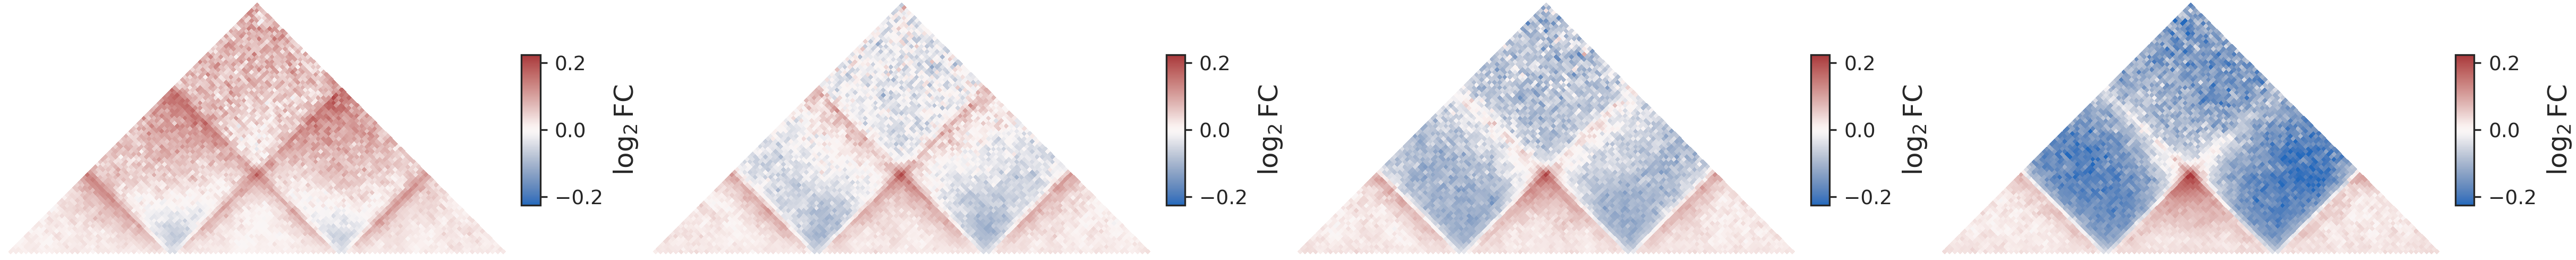

In [42]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
eps = 1e-6
diffs = {
        i: np.log2((quartile_pups[i][1]['data'][0] + eps) / (quartile_pups[i][0]['data'][0] + eps)) for i in range(1, 5)
}

vmax_diff = max(np.nanmax(diff) for diff in diffs.values())
vmin_diff = - vmax_diff

for i in range(1, 5):
    ax = axs[i-1]
    plotting.hic_upper_triangle(
        diffs[i],
        cmap="vlag",
        center=0,
        ax=ax,
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8, label=r"$\log_{2}$FC"),
        vmin=vmin_diff,
        vmax=vmax_diff
    )